# Healthcare Cost & Utilization Analytics

## Project Overview

This project analyzes patient-level healthcare data to examine healthcare utilization, patient characteristics, comorbidity burden, medication adherence, and healthcare costs among patients receiving antidiabetic treatment. The analysis focuses on identifying patterns and factors associated with post-index healthcare costs and understanding which characteristics and utilization measures are most strongly related to healthcare expenditure.

## Analytical Objective
The primary objective of this project is to identify patient characteristics and healthcare utilization measures that are most strongly associated with post-index healthcare costs.
The analysis combines exploratory data analysis, statistical hypothesis testing, correlation analysis, and multivariable regression to examine these relationships. The findings are intended to describe associations within the analyzed sample and are not intended to establish causal relationships.

## Analytical Questions

This analysis aims to answer the following questions:

1. What are the main characteristics of the patient population?

2. How do healthcare costs differ between the pre-index and post-index periods?

3. Which healthcare utilization measures are most strongly associated with post-index healthcare costs?

4. Is a higher number of recorded comorbidities associated with higher post-index healthcare costs?

5. Is medication adherence, measured using the Proportion of Days Covered (PDC), associated with post-index healthcare costs?

6.   Which variables show the strongest associations with post-index healthcare costs after accounting for multiple variables simultaneously?

7. What are the main insights and potential implications for healthcare cost management?

## Executive Summary
This project analyzes patient-level healthcare data to identify factors associated with post-index healthcare costs. 

The analysis combines exploratory data analysis, statistical hypothesis testing, correlation analysis, and multivariable regression, with a focus on healthcare utilization, comorbidity burden, and medication adherence.

### Key Findings

- Inpatient admissions showed the strongest association with post-index healthcare costs (r = 0.600, p < 0.001).
- Outpatient visits and total length of stay also showed strong positive associations with post-index costs (r = 0.551 and r = 0.503, respectively; both p < 0.001).
- Emergency room visits showed a statistically significant positive association with post-index costs (r = 0.313, p < 0.001).
- Comorbidity count showed a weaker but statistically significant positive association with post-index costs (r = 0.231, p < 0.001).
- Medication adherence, measured using the PDC ≥ 80% threshold, was not significantly associated with post-index costs in either the group comparison (Welch's t-test, p = 0.613) or the multivariable regression model (β = 191.38, p = 0.625).
- The multivariable regression model explained approximately 54.5% of the variation in post-index healthcare costs (R² = 0.545).
- Regression diagnostics suggested potential heteroscedasticity, indicating that prediction errors increased at higher predicted cost levels and that conventional OLS standard errors should therefore be interpreted cautiously.

Overall, the findings indicate that healthcare utilization measures showed stronger associations with post-index healthcare costs than medication adherence status or comorbidity count alone in this sample.

> **Important:** The results describe statistical associations within the analyzed sample and should not be interpreted as evidence of causal relationships.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading

The training and test datasets are loaded separately to preserve the original train-test structure.

The training dataset will be used as the primary dataset for exploratory and statistical analysis, while the test dataset will remain separate for potential future analytical or modeling tasks.

In [2]:
train_df = pd.read_csv("healthcareTrain.csv")
test_df = pd.read_csv("healthcareTest.csv")

In [3]:
print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

Train dataset shape: (1378, 96)
Test dataset shape: (344, 96)


In [4]:
print("\nTraining columns:", train_df.shape[1])
print("Test columns:", test_df.shape[1])


Training columns: 96
Test columns: 96


In [5]:
train_only_columns = sorted(set(train_df.columns) - set(test_df.columns))
test_only_columns = sorted(set(test_df.columns) - set(train_df.columns))

print("Columns only in training dataset:")
print(train_only_columns)

print("\nColumns only in test dataset:")
print(test_only_columns)

print("\nNumber of training-only columns:", len(train_only_columns))
print("Number of test-only columns:", len(test_only_columns))

Columns only in training dataset:
[]

Columns only in test dataset:
[]

Number of training-only columns: 0
Number of test-only columns: 0


In [6]:
derived_columns = [
    'comorbidity_burden_group',
    'comorbidity_count',
    'gpi6_utilization_group',
    'los_group',
    'ndc_utilization_group',
    'op_utilization_group',
    'total_cost_change'
]

print("Derived columns present in training dataset:")
for col in derived_columns:
    print(f"- {col}: {'YES' if col in train_df.columns else 'NO'}")

print("\nTraining dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

Derived columns present in training dataset:
- comorbidity_burden_group: NO
- comorbidity_count: NO
- gpi6_utilization_group: NO
- los_group: NO
- ndc_utilization_group: NO
- op_utilization_group: NO
- total_cost_change: NO

Training dataset shape: (1378, 96)
Test dataset shape: (344, 96)


In [7]:
# Check whether derived columns are used in the test dataset

derived_columns = [
    'comorbidity_burden_group',
    'comorbidity_count',
    'gpi6_utilization_group',
    'los_group',
    'ndc_utilization_group',
    'op_utilization_group',
    'total_cost_change'
]

print("Training derived columns:")
print(derived_columns)

print("\nCheck in test dataset:")
for col in derived_columns:
    print(f"{col}: {'FOUND' if col in test_df.columns else 'NOT FOUND'}")

Training derived columns:
['comorbidity_burden_group', 'comorbidity_count', 'gpi6_utilization_group', 'los_group', 'ndc_utilization_group', 'op_utilization_group', 'total_cost_change']

Check in test dataset:
comorbidity_burden_group: NOT FOUND
comorbidity_count: NOT FOUND
gpi6_utilization_group: NOT FOUND
los_group: NOT FOUND
ndc_utilization_group: NOT FOUND
op_utilization_group: NOT FOUND
total_cost_change: NOT FOUND


## 2.  Dataset Dimensions

The training dataset contains 1,378 patient records and 96 variables, while the test dataset contains 344 patient records and the same 96 variables.

Both datasets have the same initial feature structure. The training dataset is used as the primary dataset for exploratory and statistical analysis, while the test dataset is kept separate for potential future analytical or modeling tasks.

Additional variables are created later during data preparation and feature engineering for the analysis.

In [8]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1378 entries, 0 to 1377
Data columns (total 96 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patIndex                    1378 non-null   int64  
 1   pdc                         1378 non-null   float64
 2   num_ip_post                 1378 non-null   int64  
 3   total_los_post              1378 non-null   int64  
 4   num_op_post                 1378 non-null   int64  
 5   num_er_post                 1378 non-null   int64  
 6   num_ndc_post                1378 non-null   int64  
 7   num_gpi6_post               1378 non-null   int64  
 8   adjust_total_30d_post       1378 non-null   float64
 9   generic_rate_post           1378 non-null   float64
 10  post_ip_flag                1378 non-null   int64  
 11  post_er_flag                1378 non-null   int64  
 12  pdc_cat                     1378 non-null   int64  
 13  post_ip_cost                1378 non-null   

In [9]:
train_df.head()

,patIndex,pdc,num_ip_post,total_los_post,num_op_post,num_er_post,num_ndc_post,num_gpi6_post,adjust_total_30d_post,generic_rate_post,...,brand_cost,ratio_G_total_cost,numofgen_post,numofbrand_post,generic_cost_post,brand_cost_post,ratio_G_total_cost_post,pdc_80_flag,drug_class,patient_key
0,2393,0.500000,0,0,2,0,3,2,2.333333,1.0,...,0.000000,1.000000,3,0,39.557654,0.0,1.0,0,*ANTIDIABETICS*,322512
1,2148,0.994444,0,0,3,0,17,5,26.500000,1.0,...,19.553557,0.929937,17,0,547.646290,0.0,1.0,1,*ANTIDIABETICS*,291191
2,1799,0.472222,0,0,3,0,3,1,3.000000,1.0,...,0.000000,1.000000,3,0,8.834483,0.0,1.0,0,*ANTIDIABETICS*,251767
3,636,0.166667,0,0,0,0,2,2,2.000000,1.0,...,243.805101,NaN,2,0,8.100969,0.0,1.0,0,*ANTIDIABETICS*,80678
4,114,0.944444,0,0,3,0,12,2,12.000000,1.0,...,0.000000,1.000000,12,0,50.324328,0.0,1.0,1,*ANTIDIABETICS*,16047


In [10]:
missing_values = train_df.isnull().sum()
missing_values[missing_values > 0]

ratio_G_total_cost         53
ratio_G_total_cost_post    21
dtype: int64

In [11]:
train_df.loc[
    train_df["ratio_G_total_cost"].isna(),
    ["generic_cost", "brand_cost", "ratio_G_total_cost"]
].head(10)

,generic_cost,brand_cost,ratio_G_total_cost
3,0.0,243.805101,NaN
51,0.0,377.317367,NaN
57,0.0,1468.754548,NaN
74,0.0,0.000000,NaN
130,0.0,0.000000,NaN
147,0.0,96.755949,NaN
150,0.0,425.258559,NaN
191,0.0,0.000000,NaN
234,0.0,0.000000,NaN
235,0.0,0.000000,NaN


In [12]:
print(pd.crosstab(train_df["generic_cost"] == 0, train_df["ratio_G_total_cost"].isna()))

ratio_G_total_cost  False  True 
generic_cost                    
False                1325      0
True                    0     53


In [13]:
print(pd.crosstab(train_df["generic_cost_post"] == 0, train_df["ratio_G_total_cost_post"].isna()))

ratio_G_total_cost_post  False  True 
generic_cost_post                    
False                     1356      0
True                         1     21


## 3. Data Quality Assessment

### 3.1 Missing Values

The dataset contains missing values in two ratio variables:

- `ratio_G_total_cost`: 53 missing values
- `ratio_G_total_cost_post`: 21 missing values

Rather than imputing or removing these observations immediately, the missing-value patterns were investigated to understand their underlying cause.

### 3.2 Investigation of Missing Values

The missing values in `ratio_G_total_cost` occur exclusively when `generic_cost` is equal to zero.

Similarly, the missing values in `ratio_G_total_cost_post` occur exclusively when `generic_cost_post` is equal to zero.

This indicates that the missing ratios are structurally related to zero generic-drug costs and arise because the ratio is undefined when the denominator is zero. Therefore, these values are treated as undefined ratios and are retained as `NaN` rather than being artificially imputed.

### 3.3 Data Quality Decision

No rows will be removed because of these missing ratio values, and no mean or median imputation will be applied. The original values are preserved so that subsequent analyses can handle these variables appropriately.

## 3.4 Duplicate Records

Duplicate records can affect the reliability of the analysis by counting the same patient observation more than once.

Before continuing with the analysis, duplicate rows will therefore be checked to determine whether the training dataset contains exact duplicate records.

In [14]:
train_df.duplicated().sum()

np.int64(0)

### 3.5 Duplicate Patients

Exact duplicate rows are not the only potential duplication issue. A patient may appear in multiple records while having different values across other variables.

The `patient_key` variable is used to check whether the same patient appears more than once in the training dataset.

In [15]:
train_df["patient_key"].duplicated().sum()

np.int64(0)

The `patient_key` duplicate check identified 0 repeated patient records in the training dataset.

Combined with the exact duplicate-row check, this indicates that each patient is represented by a unique record in the training dataset.

Therefore, no observations need to be removed due to duplicate patients.

### 3.6 Numeric Data Validation

The dataset contains several numerical variables related to healthcare utilization, costs, medication adherence, and patient characteristics.

Before performing exploratory analysis, numerical variables will be reviewed for potentially unusual values, such as negative costs, invalid utilization counts, or values outside reasonable ranges.

These observations will be investigated before any decision is made to remove or modify them.

In [16]:
numeric_df = train_df.select_dtypes(include="number")

numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
patIndex,1378.0,1626.484761,1028.639396,6.000000,734.500000,1489.500000,2486.750000,3534.000000
pdc,1378.0,0.637333,0.285241,0.022222,0.411111,0.666667,0.905556,1.000000
num_ip_post,1378.0,0.090711,0.346851,0.000000,0.000000,0.000000,0.000000,3.000000
total_los_post,1378.0,0.438316,2.511449,0.000000,0.000000,0.000000,0.000000,61.000000
num_op_post,1378.0,7.309144,9.082224,0.000000,3.000000,5.000000,9.000000,180.000000
...,...,...,...,...,...,...,...,...
generic_cost_post,1378.0,309.047706,494.349939,0.000000,64.247290,145.242295,331.925823,5855.110311
brand_cost_post,1378.0,1459.533108,3324.206718,0.000000,0.000000,451.856505,1899.457011,66315.417270
ratio_G_total_cost_post,1357.0,0.460485,0.394084,0.000000,0.088645,0.313258,1.000000,1.000000
pdc_80_flag,1378.0,0.393324,0.488665,0.000000,0.000000,0.000000,1.000000,1.000000


In [17]:
negative_values = train_df.select_dtypes(include="number").lt(0).sum()
negative_values[negative_values > 0]

log_idx_copay       128
log_pre_ip_cost    1285
log_pre_er_cost    1150
log_pre_op_cost      60
log_pre_rx_cost      24
dtype: int64

In [18]:
cost_utilization_cols = [
    "pre_ip_cost",
    "pre_er_cost",
    "pre_rx_cost",
    "pre_op_cost",
    "pre_total_cost",
    "pre_medical_cost",
    "post_ip_cost",
    "post_er_cost",
    "post_rx_cost",
    "post_op_cost",
    "post_total_cost",
    "post_medical_cost",
    "generic_cost",
    "brand_cost",
    "generic_cost_post",
    "brand_cost_post",
    "adjust_total_30d",
    "adjust_total_30d_post"
]

negative_costs = train_df[cost_utilization_cols].lt(0).sum()

negative_costs[negative_costs > 0]

Series([], dtype: int64)

### Negative Value Check

The original healthcare cost and utilization variables were checked for negative values.

No negative values were identified in the selected cost and utilization variables. This confirms that the original cost and utilization measures do not contain negative observations that would require correction.

Negative values observed earlier in the `log_` variables were not treated as data-quality issues because they result from logarithmic transformations and can occur when the original values are between 0 and 1.

### 3.7 Range and Binary Variable Validation

Several variables in the dataset have clearly defined valid ranges.

The Proportion of Days Covered (PDC) should fall between 0 and 1, while binary indicator variables should contain only 0 or 1.

These constraints will be validated before continuing with the exploratory analysis.

In [19]:
print("PDC outside [0, 1]:", ((train_df["pdc"] < 0) | (train_df["pdc"] > 1)).sum())

binary_cols = [
    "post_ip_flag",
    "post_er_flag",
    "pre_ip_flag",
    "pre_er_flag",
    "pdc_80_flag"
]

for col in binary_cols:
    print(f"{col} unique values:", sorted(train_df[col].dropna().unique()))

PDC outside [0, 1]: 0
post_ip_flag unique values: [np.int64(0), np.int64(1)]
post_er_flag unique values: [np.int64(0), np.int64(1)]
pre_ip_flag unique values: [np.int64(0), np.int64(1)]
pre_er_flag unique values: [np.int64(0), np.int64(1)]
pdc_80_flag unique values: [np.int64(0), np.int64(1)]


The range validation confirmed that all PDC values fall within the valid interval of 0 to 1.

All selected binary indicator variables contain only the expected values 0 and 1. Therefore, no invalid values were identified in these variables and no corrections are required.

### 3.8 Logical Consistency Checks

Some variables represent the same healthcare utilization concept in different forms.

For inpatient utilization, `num_ip_post` records the number of inpatient admissions, while `post_ip_flag` indicates whether the patient had any inpatient admission.

The expected relationship is:

- `num_ip_post = 0` → `post_ip_flag = 0`
- `num_ip_post > 0` → `post_ip_flag = 1`

This relationship will be validated to identify any inconsistencies between the two variables.

In [20]:
ip_inconsistencies = (
    ((train_df["num_ip_post"] == 0) & (train_df["post_ip_flag"] != 0)) |
    ((train_df["num_ip_post"] > 0) & (train_df["post_ip_flag"] != 1))
).sum()

print("Inpatient flag inconsistencies:", ip_inconsistencies)

Inpatient flag inconsistencies: 0


### 3.9 Logical Consistency: Emergency Room Utilization

The same consistency check is applied to emergency room utilization.

`num_er_post` represents the number of emergency room visits, while `post_er_flag` indicates whether the patient had any emergency room utilization.

The expected relationship is:

- `num_er_post = 0` → `post_er_flag = 0`
- `num_er_post > 0` → `post_er_flag = 1`

This check validates whether the emergency room utilization count and indicator variable are consistent.

In [21]:
er_inconsistencies = (
    ((train_df["num_er_post"] == 0) & (train_df["post_er_flag"] != 0)) |
    ((train_df["num_er_post"] > 0) & (train_df["post_er_flag"] != 1))
).sum()

print("Emergency room flag inconsistencies:", er_inconsistencies)

Emergency room flag inconsistencies: 0


### 3.10 Cost Component Consistency

Healthcare costs are represented both as individual cost components and as total costs.

For the post-index period, `post_total_cost` should correspond to the combined costs of inpatient, emergency room, prescription, and outpatient services.

The relationship will be checked to identify any inconsistencies between the reported total cost and its underlying components.

In [22]:
post_cost_sum = (
    train_df["post_ip_cost"]
    + train_df["post_er_cost"]
    + train_df["post_rx_cost"]
    + train_df["post_op_cost"]
)

cost_difference = train_df["post_total_cost"] - post_cost_sum

print("Maximum absolute difference:", cost_difference.abs().max())
print("Records with non-zero difference:", (cost_difference.abs() > 0.01).sum())

Maximum absolute difference: 1.1999996786471456e-05
Records with non-zero difference: 0


The post-index total cost was validated against the sum of its underlying cost components: inpatient, emergency room, prescription, and outpatient costs.

The maximum absolute difference was approximately 0.000012, while no records showed a difference greater than the defined tolerance of 0.01.

This very small numerical difference is attributable to floating-point precision. Therefore, `post_total_cost` is considered consistent with the sum of its underlying cost components, and no correction is required.

### 3.11 Pre-index Cost Component Consistency

The same consistency check will be applied to the pre-index period.

`pre_total_cost` should correspond to the combined costs of inpatient, emergency room, prescription, and outpatient services.

This check ensures that the reported pre-index total cost is consistent with its underlying cost components.

In [23]:
pre_cost_sum = (
    train_df["pre_ip_cost"]
    + train_df["pre_er_cost"]
    + train_df["pre_rx_cost"]
    + train_df["pre_op_cost"]
)

pre_cost_difference = train_df["pre_total_cost"] - pre_cost_sum

print("Maximum absolute difference:", pre_cost_difference.abs().max())
print("Records with non-zero difference:", (pre_cost_difference.abs() > 0.01).sum())

Maximum absolute difference: 3.5500008380040526e-05
Records with non-zero difference: 0


The pre-index total cost was validated against the sum of its underlying inpatient, emergency room, prescription, and outpatient cost components.

The maximum absolute difference was approximately 0.000036, while no records showed a difference greater than the defined tolerance of 0.01.

This very small numerical difference is attributable to floating-point precision. Therefore, `pre_total_cost` is considered consistent with its underlying cost components, and no correction is required.

### **Data Quality Assessment Summary**

The training dataset underwent a series of data quality and consistency checks before exploratory analysis.

The assessment included:

- Missing-value investigation, including identification of structurally undefined ratio values.
- Exact duplicate-row detection.
- Duplicate patient identification using `patient_key`.
- Validation of negative values in original healthcare cost and utilization variables.
- Range validation for the PDC measure.
- Validation of binary indicator variables.
- Logical consistency checks between utilization counts and their corresponding indicator variables.
- Validation of pre-index and post-index total healthcare costs against their underlying cost components.

The assessment identified no exact duplicate records, no duplicate patients, no negative values in the original cost and utilization variables, and no invalid values in the validated range or binary variables.

The missing ratio values were found to be structurally related to zero generic-drug costs and were therefore retained as `NaN` rather than imputed or removed.

The pre-index and post-index total cost measures were also found to be consistent with their respective cost components within a small numerical tolerance attributable to floating-point precision.

Overall, no data-quality issues requiring row deletion, imputation, or correction were identified at this stage. The dataset is therefore considered suitable for exploratory analysis.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the characteristics, distributions, and relationships within the patient population.

The analysis focuses on patient demographics, healthcare utilization, healthcare costs, comorbidities, and medication adherence.

The objective is to identify meaningful patterns and potential factors associated with differences in post-index healthcare costs.

## 4.1 Patient Population Overview

The first stage of the exploratory analysis examines the overall patient population.

Key characteristics such as age group, sex, region, and medication adherence will be reviewed to understand the composition of the dataset before analyzing healthcare utilization and costs.

In [24]:
train_df["age_grpN"].value_counts().sort_index()

age_grpN
2    417
3    866
4     95
Name: count, dtype: int64

In [25]:
train_df[["age_grpN", "age_cat"]].drop_duplicates().sort_values("age_grpN")

,age_grpN,age_cat
3,2,2
8,2,1
0,3,3
1,3,4
22,4,5
576,4,6


In [26]:
print("age_grpN unique values:")
print(sorted(train_df["age_grpN"].unique()))

print("\nage_cat unique values:")
print(sorted(train_df["age_cat"].unique()))

print("\nAge group mapping:")
print(
    train_df[["age_grpN", "age_cat"]]
    .drop_duplicates()
    .sort_values(["age_grpN", "age_cat"])
    .to_string(index=False)
)

age_grpN unique values:
[np.int64(2), np.int64(3), np.int64(4)]

age_cat unique values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Age group mapping:
 age_grpN  age_cat
        2        1
        2        2
        3        3
        3        4
        4        5
        4        6


In [27]:
[c for c in train_df.columns if "age" in c.lower()]

['age_grpN', 'age_cat']

### 4.2 Age Group Distribution

The training dataset contains 1,378 patient records distributed across three broader age-group categories.

The distribution is concentrated in `age_grpN = 3`, followed by `age_grpN = 2`, while `age_grpN = 4` represents the smallest group.

The dataset does not contain a continuous age variable or documentation defining the exact age ranges represented by these codes. Therefore, the analysis uses the coded age groups without assigning unsupported age ranges.

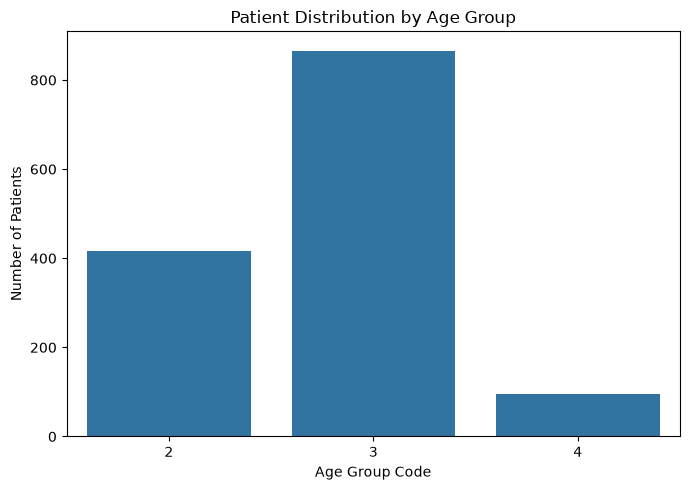

In [28]:
age_group_counts = (
    train_df["age_grpN"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=age_group_counts.index.astype(str),
    y=age_group_counts.values
)

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group Code")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### Age Group Distribution — Interpretation

The patient population is unevenly distributed across the three broader age-group categories.

age_grpN = 3 represents the largest group, with 866 patients (62.8% of the training dataset). 
age_grpN = 2 includes 417 patients (30.3%), while age_grpN = 4 is the smallest group with 95 patients (6.9%).


This indicates that the analyzed population is concentrated in age_grpN = 3. However, because the dataset does not provide the underlying age ranges, no conclusions about specific age ranges can be drawn from these codes alone.

### 4.3 Sex Distribution

The distribution of patients by sex will be examined to understand the demographic composition of the training population.

Because `sexN` is stored as a numeric code, the analysis will first examine its unique values and frequencies before assigning any interpretation to the categories.

In [29]:
train_df["sexN"].value_counts().sort_index()

sexN
1    698
2    680
Name: count, dtype: int64

In [30]:
print("sexN unique values:")
print(sorted(train_df["sexN"].unique()))

print("\nSex distribution:")
print(
    train_df["sexN"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

sexN unique values:
[np.int64(1), np.int64(2)]

Sex distribution:
sexN
1    50.7
2    49.3
Name: proportion, dtype: float64


### Sex Distribution — Interpretation

The training dataset contains 1,378 patient records and shows a nearly balanced distribution across the two sex codes.

Sex Code 1 represents 698 patients (50.7%), while Sex Code 2 represents 680 patients (49.3%).

The difference between the two groups is small, indicating that the patient population is relatively balanced across the available sex categories.

Because the dataset does not provide a documented mapping between the numeric codes and specific sex labels, the categories are retained as Sex Code 1 and Sex Code 2 without assigning unsupported labels.

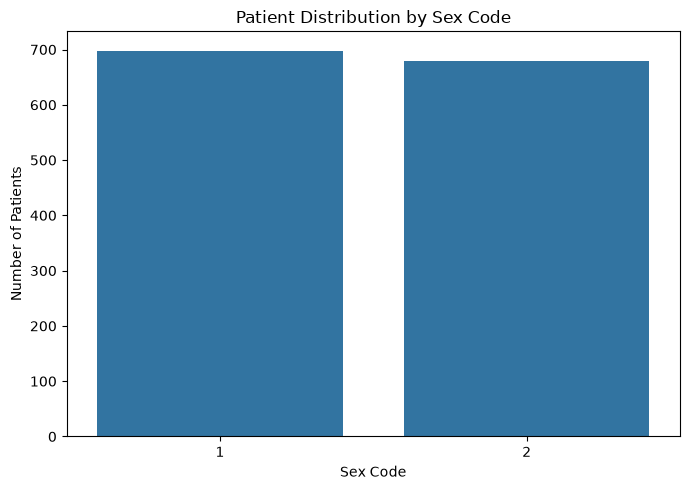

In [31]:
sex_counts = (
    train_df["sexN"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=sex_counts.index.astype(str),
    y=sex_counts.values
)

plt.title("Patient Distribution by Sex Code")
plt.xlabel("Sex Code")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### 4.4 Region Distribution

The geographic distribution of the patient population will be examined using the `regionN` variable.

Because `regionN` is stored as a numeric code, the available categories and their frequencies will first be examined before assigning any geographic interpretation.

In [32]:
print("Region codes:")
print(sorted(train_df["regionN"].unique()))

print("\nRegion distribution:")
print(train_df["regionN"].value_counts().sort_index())

Region codes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Region distribution:
regionN
1    111
2    401
3    774
4     92
Name: count, dtype: int64


### Region Distribution — Interpretation

The patient population is distributed across four coded geographic categories.

Region Code 3 represents the largest group, with 774 patients (56.2% of the training dataset). Region Code 2 includes 401 patients (29.1%), while Region Codes 1 and 4 represent smaller groups with 111 patients (8.1%) and 92 patients (6.7%), respectively.

The distribution is therefore concentrated in Region Code 3.

Because the dataset does not provide a documented mapping between the numeric codes and specific geographic regions, the categories are retained as coded values without assigning unsupported geographic labels.

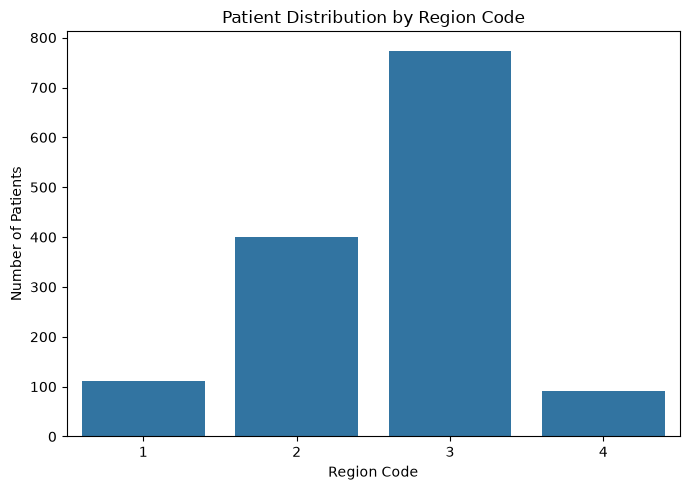

In [33]:
region_counts = (
    train_df["regionN"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=region_counts.index.astype(str),
    y=region_counts.values
)

plt.title("Patient Distribution by Region Code")
plt.xlabel("Region Code")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### 4.5 Medication Adherence — Proportion of Days Covered (PDC)

Proportion of Days Covered (PDC) is used as a measure of medication adherence.

The PDC variable ranges from 0 to 1, where higher values indicate a greater proportion of days covered by the medication.

The distribution of PDC will first be examined to understand the overall medication-adherence profile of the patient population.

In [34]:
train_df["pdc"].describe()

count    1378.000000
mean        0.637333
std         0.285241
min         0.022222
25%         0.411111
50%         0.666667
75%         0.905556
max         1.000000
Name: pdc, dtype: float64

### PDC Distribution — Interpretation

The PDC distribution shows substantial variation in medication adherence across the patient population.

The mean PDC was 0.637, corresponding to an average proportion of approximately 63.7% of days covered across the analyzed observations. 

The median PDC was 0.667, while the middle 50% of observations ranged from approximately 0.411 to 0.906.
PDC values ranged from 0.022 to 1.000, indicating substantial variation in medication coverage, from very low coverage to complete coverage.


The relatively wide distribution suggests considerable variation in medication adherence across the population.

This makes PDC a relevant variable for further analysis of its relationship with healthcare utilization and post-index healthcare costs.

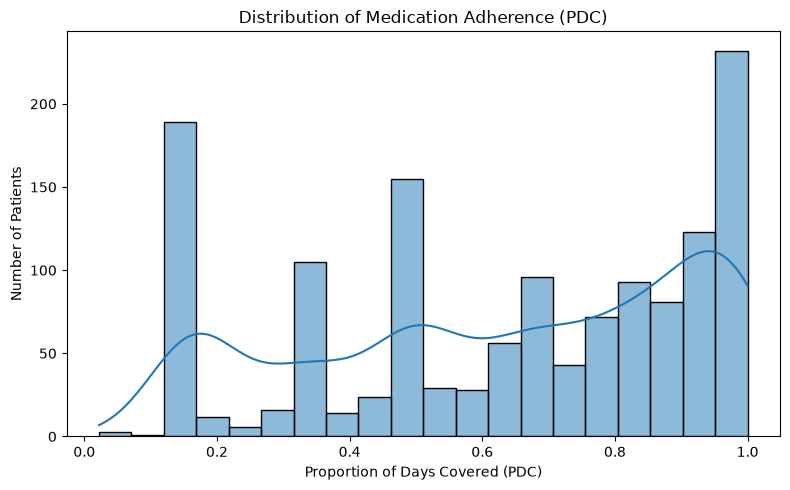

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(
    train_df["pdc"],
    bins=20,
    kde=True
)

plt.title("Distribution of Medication Adherence (PDC)")
plt.xlabel("Proportion of Days Covered (PDC)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### 4.6 Medication Adherence Groups

A PDC threshold of 80% is commonly used to distinguish higher medication adherence from lower adherence in healthcare analytics.

The dataset contains the derived variable `pdc_80_flag`, which identifies patients meeting the 80% PDC threshold.

The distribution of this indicator will be examined to understand how many patients fall into the higher-adherence group compared with the lower-adherence group.

In [36]:
pdc_80_counts = (
    train_df["pdc_80_flag"]
    .value_counts()
    .sort_index()
)

pdc_80_percentage = (
    train_df["pdc_80_flag"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

print("Patient counts:")
print(pdc_80_counts)

print("\nPatient percentages:")
print(pdc_80_percentage)

Patient counts:
pdc_80_flag
0    836
1    542
Name: count, dtype: int64

Patient percentages:
pdc_80_flag
0    60.7
1    39.3
Name: proportion, dtype: float64


### PDC ≥ 80% — Interpretation

The PDC-based adherence classification shows that 542 patients (39.3%) meet or exceed the 80% adherence threshold, while 836 patients (60.7%) have a PDC below 80%.

Therefore, the majority of patients in the training dataset fall below the defined higher-adherence threshold.

This finding provides an important baseline for later analysis of whether medication adherence is associated with differences in healthcare utilization and post-index healthcare costs.

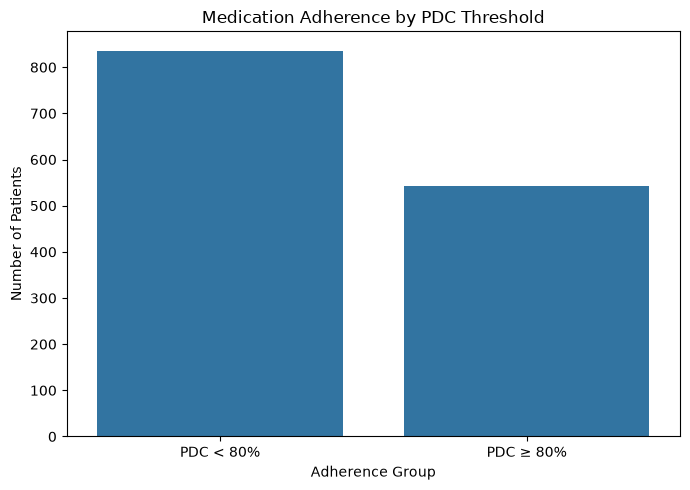

In [37]:
pdc_80_labels = {
    0: "PDC < 80%",
    1: "PDC ≥ 80%"
}

pdc_80_plot = train_df["pdc_80_flag"].map(pdc_80_labels).value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=pdc_80_plot.index,
    y=pdc_80_plot.values
)

plt.title("Medication Adherence by PDC Threshold")
plt.xlabel("Adherence Group")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

## 4.7 Healthcare Utilization

The next stage of the exploratory analysis examines healthcare utilization during the post-index period.

The analysis focuses on inpatient admissions, emergency room visits, outpatient visits, length of stay, and other utilization measures.

Understanding the distribution of healthcare utilization is important for identifying patterns that may be associated with higher post-index healthcare costs.

### 4.8 Post-index Healthcare Utilization — Descriptive Statistics

The main post-index utilization measures will first be summarized using descriptive statistics.

This provides an overview of the frequency and variability of healthcare service use across the patient population.

In [38]:
utilization_cols = [
    "num_ip_post",
    "total_los_post",
    "num_op_post",
    "num_er_post",
    "num_ndc_post",
    "num_gpi6_post"
]

train_df[utilization_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_ip_post,1378.0,0.090711,0.346851,0.0,0.0,0.0,0.0,3.0
total_los_post,1378.0,0.438316,2.511449,0.0,0.0,0.0,0.0,61.0
num_op_post,1378.0,7.309144,9.082224,0.0,3.0,5.0,9.0,180.0
num_er_post,1378.0,0.201016,0.618827,0.0,0.0,0.0,0.0,6.0
num_ndc_post,1378.0,17.539913,12.478138,1.0,9.0,15.0,23.0,87.0
num_gpi6_post,1378.0,6.999274,4.046301,1.0,4.0,6.0,9.0,26.0


### Post-index Healthcare Utilization — Interpretation

The post-index utilization measures show substantial differences in healthcare service use across the patient population.

Inpatient utilization is relatively infrequent. The mean number of inpatient admissions is 0.091 per patient, with a median of 0 and a maximum of 3 admissions. Similarly, total inpatient length of stay has a median of 0 days, with a mean of 0.438 days and a maximum of 61 days.

Emergency room utilization is also relatively low, with a mean of 0.201 visits per patient, a median of 0, and a maximum of 6 visits.

Outpatient utilization is more frequent. Patients have a mean of 7.31 outpatient visits, with a median of 5 and a maximum of 180 visits.

The medication-related utilization measures show higher activity. The mean number of NDCs is 17.54, while the mean number of GPI6 codes is approximately 7.00.

Overall, the utilization measures show a highly uneven distribution, with many patients having little or no inpatient or emergency utilization while outpatient and medication-related utilization are more common.

In [39]:
utilization_plot_cols = [
    "num_ip_post",
    "num_er_post",
    "num_op_post"
]

utilization_plot_data = train_df[utilization_plot_cols].rename(
    columns={
        "num_ip_post": "Inpatient Admissions",
        "num_er_post": "ER Visits",
        "num_op_post": "Outpatient Visits"
    }
)

utilization_plot_data.mean().sort_values(ascending=False)

Outpatient Visits       7.309144
ER Visits               0.201016
Inpatient Admissions    0.090711
dtype: float64

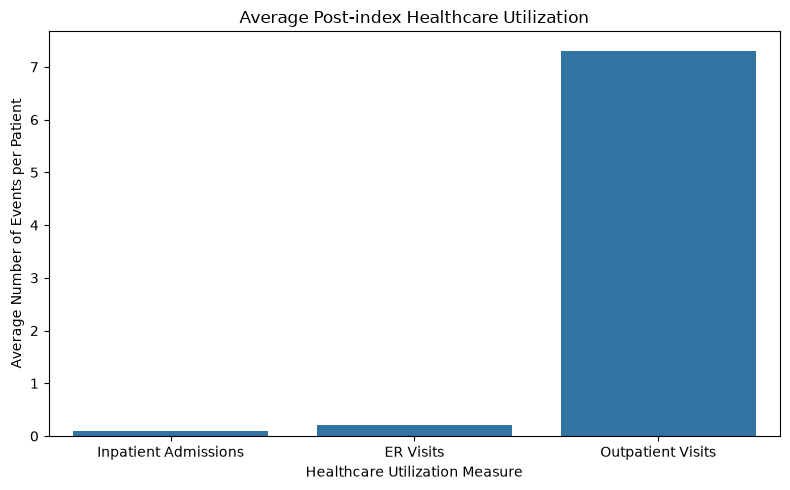

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=utilization_plot_data.mean().index,
    y=utilization_plot_data.mean().values
)

plt.title("Average Post-index Healthcare Utilization")
plt.xlabel("Healthcare Utilization Measure")
plt.ylabel("Average Number of Events per Patient")

plt.tight_layout()
plt.show()

### Healthcare Utilization — Visualization Interpretation

The visualization highlights a substantial difference in the average frequency of healthcare service use.

Outpatient visits are considerably more frequent than inpatient admissions or emergency room visits, with an average of 7.31 outpatient visits per patient compared with 0.20 emergency room visits and 0.09 inpatient admissions.

This pattern indicates that outpatient care represents the most frequent form of healthcare utilization in the post-index period, while inpatient and emergency services are used less frequently across the overall population.

### 4.9 Patients with Healthcare Utilization

Average utilization alone does not show how many patients actually used each type of healthcare service.

The proportion of patients with at least one inpatient admission, emergency room visit, or outpatient visit will therefore be examined.

In [41]:
utilization_flags = pd.DataFrame({
    "Inpatient Admissions": (train_df["num_ip_post"] > 0),
    "ER Visits": (train_df["num_er_post"] > 0),
    "Outpatient Visits": (train_df["num_op_post"] > 0)
})

utilization_summary = pd.DataFrame({
    "Patients with utilization": utilization_flags.sum(),
    "Percentage of patients": (utilization_flags.mean() * 100).round(1)
})

utilization_summary

,Patients with utilization,Percentage of patients
Inpatient Admissions,103,7.5
ER Visits,181,13.1
Outpatient Visits,1309,95.0


### Patients with Healthcare Utilization — Interpretation

The proportion of patients with at least one healthcare utilization event differs substantially across service types.

Outpatient care is highly prevalent, with 1,309 patients (95.0%) having at least one outpatient visit during the post-index period.

In contrast, 181 patients (13.1%) had at least one emergency room visit, while only 103 patients (7.5%) had at least one inpatient admission.

This finding confirms that outpatient care is the most widespread form of healthcare utilization in the population, whereas inpatient and emergency services are concentrated among a smaller subset of patients.

The difference between the prevalence of utilization and the average number of events also highlights the importance of examining both measures in subsequent cost analyses.

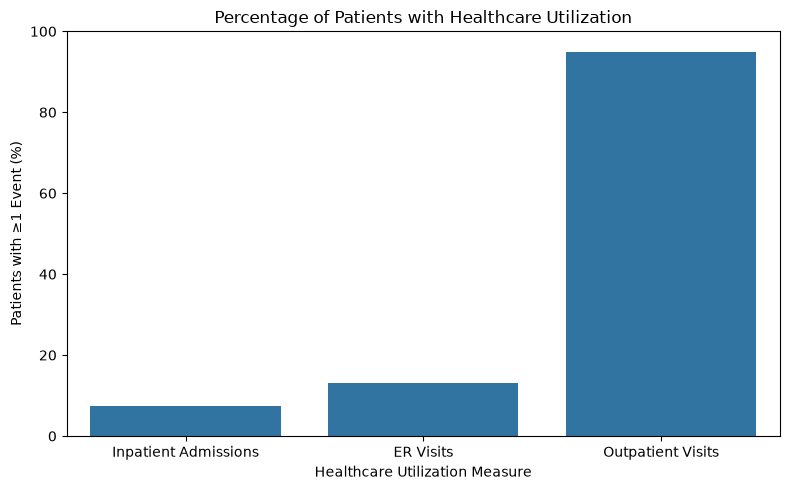

In [42]:
utilization_prevalence = utilization_summary["Percentage of patients"]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=utilization_prevalence.index,
    y=utilization_prevalence.values
)

plt.title("Percentage of Patients with Healthcare Utilization")
plt.xlabel("Healthcare Utilization Measure")
plt.ylabel("Patients with ≥1 Event (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### 4.10 Post-index Length of Stay

Length of Stay (LOS) measures the total number of inpatient days during the post-index period.

Because inpatient admissions are relatively uncommon in this population, the distribution of LOS will be examined separately to identify the proportion of patients with inpatient stays and the degree of variation among those patients.

In [43]:
los_summary = pd.DataFrame({
    "Patients with LOS > 0": [
        (train_df["total_los_post"] > 0).sum()
    ],
    "Percentage of patients": [
        (train_df["total_los_post"] > 0).mean() * 100
    ],
    "Mean LOS among all patients": [
        train_df["total_los_post"].mean()
    ],
    "Mean LOS among patients with LOS > 0": [
        train_df.loc[
            train_df["total_los_post"] > 0,
            "total_los_post"
        ].mean()
    ],
    "Maximum LOS": [
        train_df["total_los_post"].max()
    ]
})

los_summary.round(2)

,Patients with LOS > 0,Percentage of patients,Mean LOS among all patients,Mean LOS among patients with LOS > 0,Maximum LOS
0,103,7.47,0.44,5.86,61


### Length of Stay — Interpretation

Post-index inpatient length of stay is concentrated among a relatively small proportion of the patient population.

A total of 103 patients (7.47%) have a length of stay greater than zero, while the remaining patients have no recorded inpatient stay during the post-index period.

The mean length of stay across all patients is only 0.44 days. However, among patients with at least one inpatient day, the mean length of stay increases to 5.86 days.

The maximum observed length of stay is 61 days, indicating substantial variation among patients who required inpatient care.

This difference between the overall mean and the mean among patients with an inpatient stay demonstrates that healthcare utilization is highly concentrated and should be considered carefully in subsequent cost analyses.

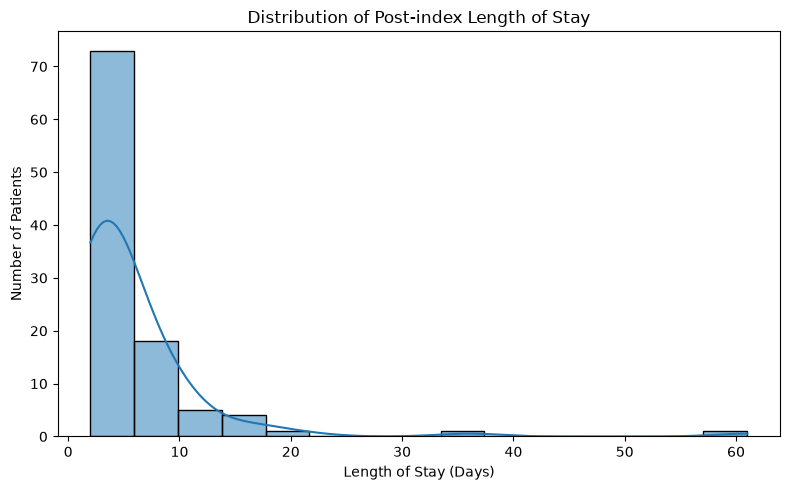

In [44]:
los_positive = train_df.loc[
    train_df["total_los_post"] > 0,
    "total_los_post"
]

plt.figure(figsize=(8, 5))

sns.histplot(
    los_positive,
    bins=15,
    kde=True
)

plt.title("Distribution of Post-index Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### 4.11 Post-index Medication Utilization

Medication-related utilization is assessed using the number of unique NDC and GPI6 medication codes recorded during the post-index period.

These measures provide an indication of the breadth of medication utilization and will be summarized to understand their distribution across the patient population.

In [45]:
medication_utilization_cols = [
    "num_ndc_post",
    "num_gpi6_post"
]

train_df[medication_utilization_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_ndc_post,1378.0,17.539913,12.478138,1.0,9.0,15.0,23.0,87.0
num_gpi6_post,1378.0,6.999274,4.046301,1.0,4.0,6.0,9.0,26.0


In [46]:
medication_utilization_summary = pd.DataFrame({
    "Patients with NDC utilization": [
        (train_df["num_ndc_post"] > 0).sum()
    ],
    "Patients with GPI6 utilization": [
        (train_df["num_gpi6_post"] > 0).sum()
    ],
    "NDC utilization rate (%)": [
        (train_df["num_ndc_post"] > 0).mean() * 100
    ],
    "GPI6 utilization rate (%)": [
        (train_df["num_gpi6_post"] > 0).mean() * 100
    ]
})

medication_utilization_summary.round(1)

,Patients with NDC utilization,Patients with GPI6 utilization,NDC utilization rate (%),GPI6 utilization rate (%)
0,1378,1378,100.0,100.0


### Medication Utilization — Interpretation

Medication-related utilization is present across the entire training population.

All 1,378 patients (100%) have at least one recorded NDC medication code and at least one recorded GPI6 medication code during the post-index period.

The mean number of NDC codes is 17.54, compared with a mean of approximately 7.00 GPI6 codes per patient. The maximum values are 87 NDC codes and 26 GPI6 codes, indicating substantial variation in the breadth of medication utilization across patients.

Because medication utilization is present for all patients, the number of medication codes is more informative as a measure of utilization intensity or breadth than as an indicator of whether medication utilization occurred.

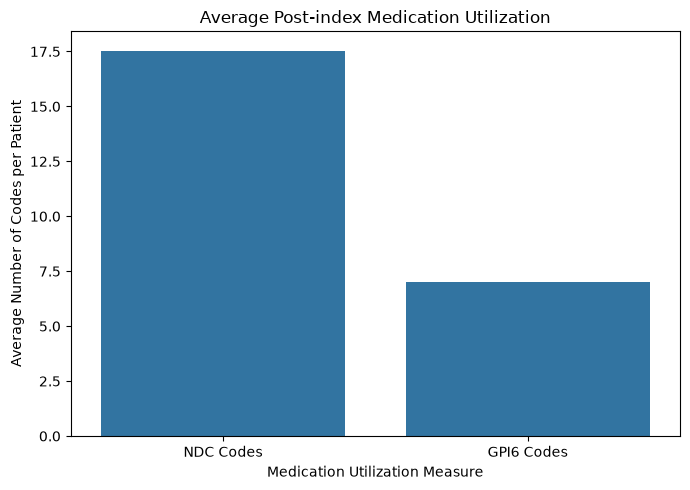

In [47]:
medication_means = train_df[
    ["num_ndc_post", "num_gpi6_post"]
].mean()

medication_labels = {
    "num_ndc_post": "NDC Codes",
    "num_gpi6_post": "GPI6 Codes"
}

medication_means.index = medication_means.index.map(medication_labels)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=medication_means.index,
    y=medication_means.values
)

plt.title("Average Post-index Medication Utilization")
plt.xlabel("Medication Utilization Measure")
plt.ylabel("Average Number of Codes per Patient")

plt.tight_layout()
plt.show()

## 5 .Healthcare Cost Analysis

The next stage of the exploratory analysis examines healthcare costs before and after the index period.

The analysis will compare pre-index and post-index costs across inpatient, emergency, prescription, outpatient, and total medical cost categories.

The objective is to understand the overall cost structure and identify differences between the pre-index and post-index periods before investigating factors associated with higher costs.

#### 5.1 Pre-index vs Post-index Cost Summary

Healthcare costs are available for both the pre-index and post-index periods.

The following summary compares the main cost categories across the two periods using mean, median, and maximum values.

In [48]:
cost_cols = [
    "pre_ip_cost",
    "pre_er_cost",
    "pre_rx_cost",
    "pre_op_cost",
    "pre_total_cost",
    "pre_medical_cost",
    "post_ip_cost",
    "post_er_cost",
    "post_rx_cost",
    "post_op_cost",
    "post_total_cost",
    "post_medical_cost"
]

cost_summary = train_df[cost_cols].agg(
    ["mean", "median", "max"]
).T

cost_summary

,mean,median,max
pre_ip_cost,1543.075024,0.000000,98367.36411
pre_er_cost,178.920100,0.000000,27842.54228
pre_rx_cost,1355.586192,456.249937,50250.77830
pre_op_cost,2059.910935,769.112339,71500.45677
pre_total_cost,5137.492252,1974.442045,103510.80220
pre_medical_cost,3781.906060,879.064599,101506.67700
post_ip_cost,1306.615910,0.000000,72568.39400
post_er_cost,174.229041,0.000000,17651.89668
post_rx_cost,1905.356702,800.357748,66425.39718
post_op_cost,2585.810871,812.241375,60020.80430


### Pre-index vs Post-index Cost Summary — Interpretation

The comparison between the pre-index and post-index periods shows an increase in overall healthcare costs.

Mean total cost increased from 5,137.49 in the pre-index period to 5,972.01 in the post-index period. The median total cost also increased from 1,974.44 to 2,539.70.

The largest increases in mean cost were observed for prescription costs, which increased from 1,355.59 to 1,905.36, and outpatient costs, which increased from 2,059.91 to 2,585.81.

In contrast, mean inpatient costs decreased from 1,543.08 to 1,306.62, while emergency room costs remained relatively stable, decreasing slightly from 178.92 to 174.23.

Mean medical cost increased from 3,781.91 to 4,066.66.

Although post-index mean and median total costs are higher, the maximum total cost is lower in the post-index period. This indicates that healthcare costs are highly variable and should not be characterized using a single summary statistic.

These descriptive findings do not establish that the index period caused the observed cost changes. They provide a basis for further analysis of factors associated with post-index healthcare costs.

In [49]:
cost_comparison = pd.DataFrame({
    "Pre-index": [
        train_df["pre_ip_cost"].mean(),
        train_df["pre_er_cost"].mean(),
        train_df["pre_rx_cost"].mean(),
        train_df["pre_op_cost"].mean(),
        train_df["pre_total_cost"].mean(),
        train_df["pre_medical_cost"].mean()
    ],
    "Post-index": [
        train_df["post_ip_cost"].mean(),
        train_df["post_er_cost"].mean(),
        train_df["post_rx_cost"].mean(),
        train_df["post_op_cost"].mean(),
        train_df["post_total_cost"].mean(),
        train_df["post_medical_cost"].mean()
    ]
}, index=[
    "Inpatient",
    "ER",
    "Prescription",
    "Outpatient",
    "Total Cost",
    "Medical Cost"
])

cost_comparison

,Pre-index,Post-index
Inpatient,1543.075024,1306.615910
ER,178.920100,174.229041
Prescription,1355.586192,1905.356702
Outpatient,2059.910935,2585.810871
Total Cost,5137.492252,5972.012523
Medical Cost,3781.906060,4066.655821


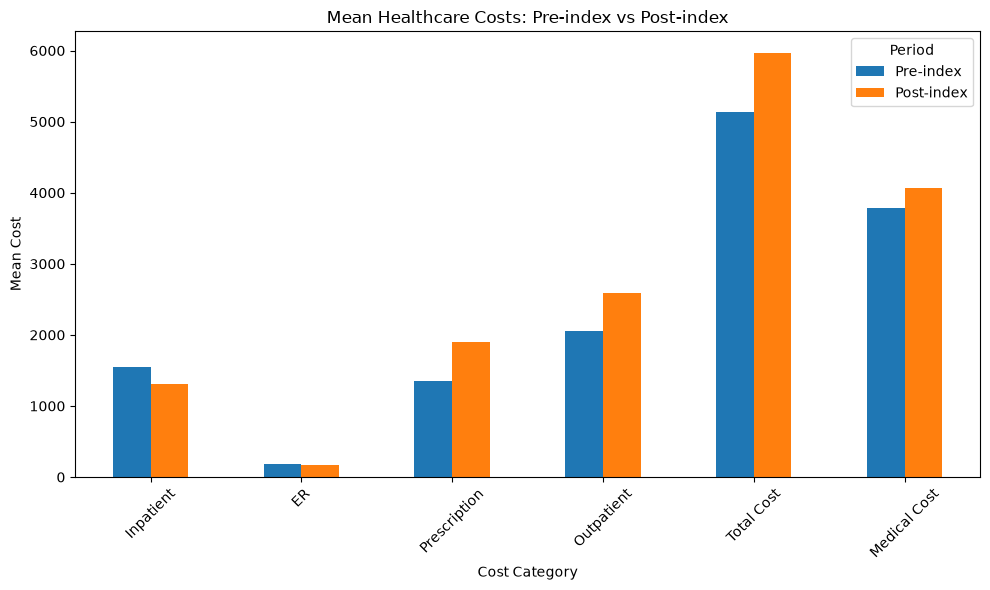

In [50]:
cost_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Mean Healthcare Costs: Pre-index vs Post-index")
plt.xlabel("Cost Category")
plt.ylabel("Mean Cost")

plt.xticks(rotation=45)
plt.legend(title="Period")

plt.tight_layout()
plt.show()

### Pre-index vs Post-index Cost Comparison — Interpretation

The comparison shows that mean healthcare costs increased in the post-index period for most major cost categories.

The largest increases are observed in prescription and outpatient costs. Mean prescription cost increased from 1,355.59 in the pre-index period to 1,905.36 post-index, while mean outpatient cost increased from 2,059.91 to 2,585.81.

As a result, mean total healthcare cost increased from 5,137.49 to 5,972.01, representing an increase of approximately 16.2%.

Mean medical cost also increased from 3,781.91 to 4,066.66.

In contrast, mean inpatient cost decreased from 1,543.08 to 1,306.62, and mean emergency room cost remained relatively stable.

Overall, the descriptive comparison shows that the largest increases in mean cost were observed for prescription and outpatient costs, while inpatient and emergency room costs decreased slightly.

These results describe differences between the two periods and should not be interpreted as evidence of causality.

### 5.2 Change in Total Healthcare Cost

To examine patient-level changes in healthcare spending, the difference between post-index and pre-index total healthcare cost will be calculated for each patient.

A positive value indicates an increase in total cost after the index period, while a negative value indicates a decrease.

In [51]:
train_df["total_cost_change"] = (
    train_df["post_total_cost"] - train_df["pre_total_cost"]
)

train_df["total_cost_change"].describe()

count     1378.000000
mean       834.520271
std      11700.915163
min     -99305.443551
25%       -780.824540
50%        247.848226
75%       2212.395881
max      79914.674749
Name: total_cost_change, dtype: float64

### Change in Total Healthcare Cost — Interpretation

The patient-level change in total healthcare cost shows substantial variation between the pre-index and post-index periods.

The mean change is +834.52, indicating that total healthcare costs increased on average by approximately 834.52 per patient.

The median change is +247.85, which also indicates an overall upward shift in post-index costs. However, the distribution is highly variable, with the middle 50% of patients ranging from a decrease of 780.82 to an increase of 2,212.40.

The observed changes range from a maximum decrease of 99,305.44 to a maximum increase of 79,914.67.

The large difference between the mean and the standard deviation, together with the wide range of observed changes, indicates substantial heterogeneity and the presence of extreme cost changes.

These findings highlight the importance of examining the distribution and potential outliers before conducting further cost-association analyses.

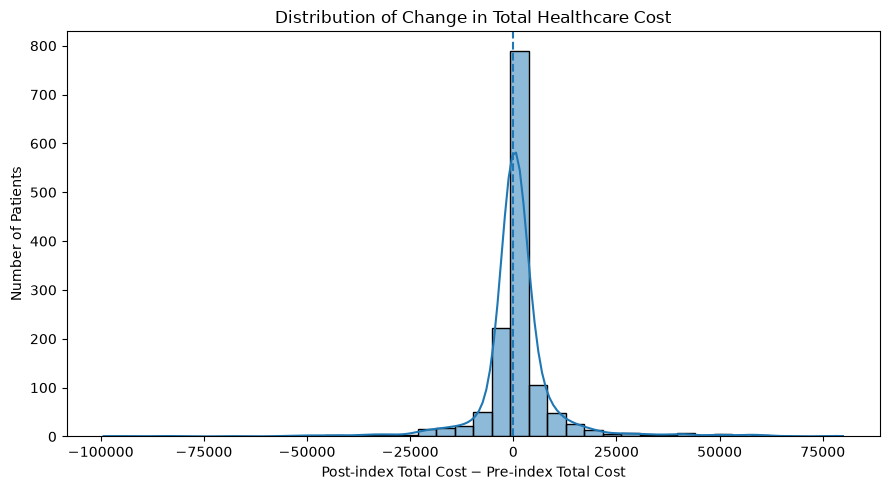

In [52]:
plt.figure(figsize=(9, 5))

sns.histplot(
    train_df["total_cost_change"],
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title("Distribution of Change in Total Healthcare Cost")
plt.xlabel("Post-index Total Cost − Pre-index Total Cost")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### Cost Change Distribution — Interpretation

The distribution of patient-level total cost changes shows substantial heterogeneity between the pre-index and post-index periods.

The vertical reference line at zero separates patients whose total healthcare costs decreased from those whose costs increased.

Most observations are concentrated relatively close to zero, but the distribution has long tails in both directions. This indicates that a smaller group of patients experienced substantially larger increases or decreases in healthcare costs.

The presence of extreme changes is consistent with the large range and standard deviation observed in the descriptive statistics.

Therefore, subsequent analyses should consider the skewed and heterogeneous nature of healthcare cost changes and avoid relying exclusively on mean values.

### 5.3 Patients with Increased vs Decreased Total Cost

To complement the continuous cost-change analysis, patients will be classified according to whether their post-index total healthcare cost increased, decreased, or remained unchanged relative to the pre-index period.

In [53]:
cost_change_group = pd.Series(
    np.select(
        [
            train_df["total_cost_change"] > 0,
            train_df["total_cost_change"] < 0,
            train_df["total_cost_change"] == 0
        ],
        [
            "Cost Increased",
            "Cost Decreased",
            "No Change"
        ],
        default="Unknown"
    ),
    name="cost_change_group"
)

cost_change_summary = pd.DataFrame({
    "Patients": cost_change_group.value_counts(),
    "Percentage": (
        cost_change_group.value_counts(normalize=True) * 100
    ).round(1)
})

cost_change_summary

,Patients,Percentage
cost_change_group,,
Cost Increased,790,57.3
Cost Decreased,588,42.7


### Increased vs Decreased Total Cost — Interpretation

The patient-level comparison shows that 790 patients (57.3%) experienced an increase in total healthcare costs during the post-index period, while 588 patients (42.7%) experienced a decrease.

No patients had exactly the same total healthcare cost in both periods.

Although the overall mean change was positive, the distribution of individual patient changes is heterogeneous, with a substantial proportion of patients experiencing decreased costs.

This finding reinforces the importance of examining patient-level cost changes rather than relying only on aggregate mean costs.

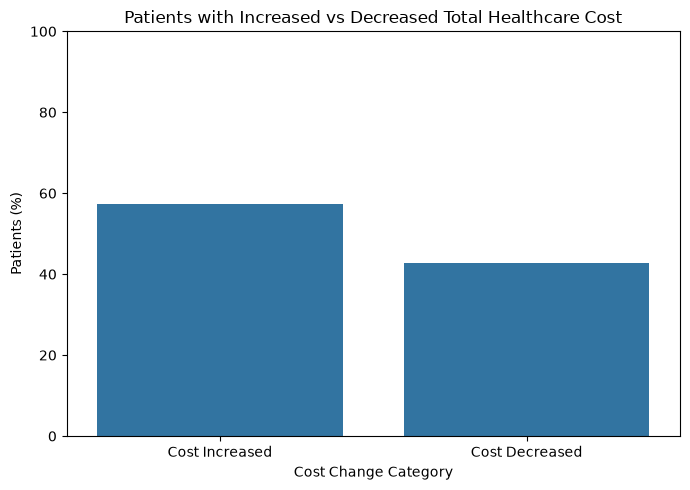

In [54]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=cost_change_summary.index,
    y=cost_change_summary["Percentage"]
)

plt.title("Patients with Increased vs Decreased Total Healthcare Cost")
plt.xlabel("Cost Change Category")
plt.ylabel("Patients (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## 5.4 Comorbidity Analysis

The next stage examines the prevalence of common comorbidities within the patient population.

The dataset contains binary indicators for multiple chronic conditions. These variables will be used to assess the prevalence of individual comorbidities and later examine whether comorbidity burden is associated with higher post-index healthcare costs.

In [55]:
comorbidity_cols = [
    "ALCOHOL_DRUG",
    "ASTHMA",
    "CARDIAC_ARRYTHMIA",
    "CARDIAC_VALVULAR",
    "CEREBROVASCULAR",
    "CHRONIC_KIDNEY",
    "CHRONIC_PAIN_FIBRO",
    "CHF",
    "COPD",
    "DEMENTIA",
    "DEPRESSION",
    "DIABETES",
    "DYSLIPIDEMIA",
    "EPILEPSY_SEIZURE",
    "HEPATITIS",
    "HIV_AIDS",
    "HYPERTENSION",
    "LIVER_GALLBLADDER_PANCREAS",
    "MI_CAD",
    "OSTEOARTHRITIS",
    "PARALYSIS",
    "PEPTIC_ULCER",
    "PERIPHERAL_VASCULAR",
    "RENAL_FAILURE",
    "RHEUMATOLOGIC",
    "SCHIZOPHRENIA",
    "SLEEP_DISORDERS",
    "SMOKING",
    "THYROID",
    "Solid_Tumor",
    "Metastatic",
    "Leukemia_Lymphoma",
    "Other_Cancer",
    "Cancer_In_Situ"
]

len(comorbidity_cols)

34

### 5.5 Comorbidity Coding Validation

The comorbidity indicators are expected to be binary variables, where 0 represents the absence of a condition and 1 represents its presence.

The unique values of each comorbidity indicator will be checked to confirm that the variables follow the expected binary structure.

In [56]:
comorbidity_unique_values = {
    col: sorted(train_df[col].dropna().unique().tolist())
    for col in comorbidity_cols
}

comorbidity_unique_values

{'ALCOHOL_DRUG': [0, 1],
 'ASTHMA': [0, 1],
 'CARDIAC_ARRYTHMIA': [0, 1],
 'CARDIAC_VALVULAR': [0, 1],
 'CEREBROVASCULAR': [0, 1],
 'CHRONIC_KIDNEY': [0, 1],
 'CHRONIC_PAIN_FIBRO': [0, 1],
 'CHF': [0, 1],
 'COPD': [0, 1],
 'DEMENTIA': [0, 1],
 'DEPRESSION': [0, 1],
 'DIABETES': [0, 1],
 'DYSLIPIDEMIA': [0, 1],
 'EPILEPSY_SEIZURE': [0, 1],
 'HEPATITIS': [0, 1],
 'HIV_AIDS': [0, 1],
 'HYPERTENSION': [0, 1],
 'LIVER_GALLBLADDER_PANCREAS': [0, 1],
 'MI_CAD': [0, 1],
 'OSTEOARTHRITIS': [0, 1],
 'PARALYSIS': [0, 1],
 'PEPTIC_ULCER': [0, 1],
 'PERIPHERAL_VASCULAR': [0, 1],
 'RENAL_FAILURE': [0, 1],
 'RHEUMATOLOGIC': [0, 1],
 'SCHIZOPHRENIA': [0, 1],
 'SLEEP_DISORDERS': [0, 1],
 'SMOKING': [0, 1],
 'THYROID': [0, 1],
 'Solid_Tumor': [0, 1],
 'Metastatic': [0, 1],
 'Leukemia_Lymphoma': [0, 1],
 'Other_Cancer': [0, 1],
 'Cancer_In_Situ': [0, 1]}

### 5.6 Comorbidity Prevalence

The prevalence of each comorbidity will be calculated to identify the most common conditions within the patient population.

Both the number and percentage of patients with each condition will be reported. This provides an overview of the clinical characteristics of the population before examining the relationship between comorbidity burden and healthcare costs.

In [57]:
comorbidity_prevalence = pd.DataFrame({
    "Patients": train_df[comorbidity_cols].sum(),
    "Percentage": (
        train_df[comorbidity_cols].mean() * 100
    ).round(1)
})

comorbidity_prevalence = comorbidity_prevalence.sort_values(
    "Percentage",
    ascending=False
)

comorbidity_prevalence

,Patients,Percentage
DIABETES,859,62.3
HYPERTENSION,605,43.9
DYSLIPIDEMIA,594,43.1
OSTEOARTHRITIS,263,19.1
SLEEP_DISORDERS,139,10.1
THYROID,111,8.1
SMOKING,73,5.3
MI_CAD,69,5.0
DEPRESSION,65,4.7
LIVER_GALLBLADDER_PANCREAS,61,4.4


### Most Prevalent Comorbidities

To improve interpretability, the visualization focuses on the ten most prevalent comorbidities rather than displaying all conditions simultaneously.

This approach highlights the dominant clinical characteristics of the patient population while avoiding an overly dense visualization.

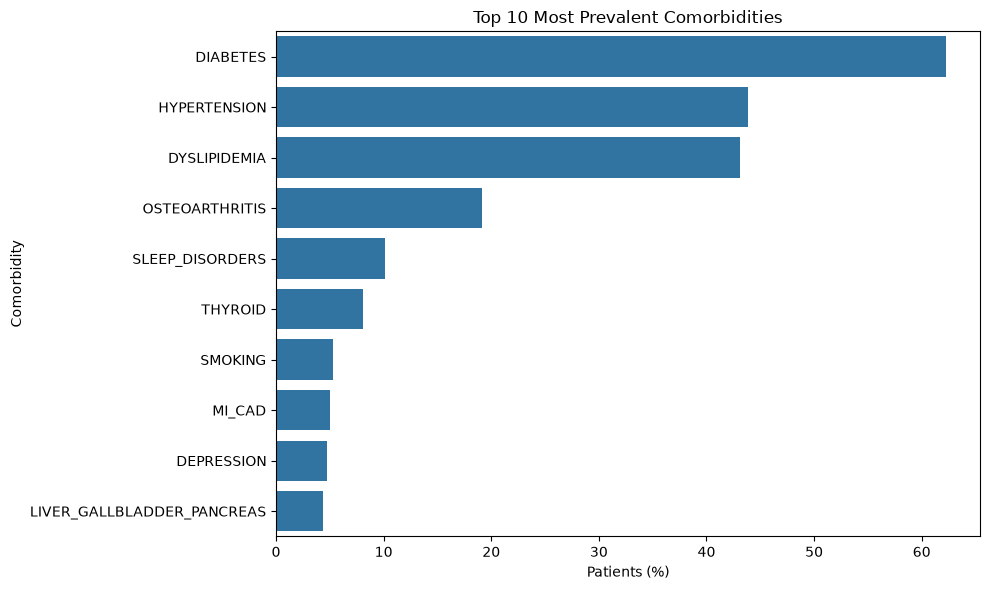

In [58]:
top_comorbidities = comorbidity_prevalence.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_comorbidities.reset_index(),
    x="Percentage",
    y="index"
)

plt.title("Top 10 Most Prevalent Comorbidities")
plt.xlabel("Patients (%)")
plt.ylabel("Comorbidity")

plt.tight_layout()
plt.show()

### Comorbidity Prevalence — Interpretation

The comorbidity profile shows that diabetes is the most prevalent condition in the study population, affecting 62.3% of patients.

Hypertension and dyslipidemia are also highly prevalent, affecting 43.9% and 43.1% of patients, respectively. Osteoarthritis is the fourth most common condition, present in 19.1% of patients.

The remaining conditions have substantially lower prevalence, with sleep disorders and thyroid conditions affecting 10.1% and 8.1% of patients, respectively.

Overall, the population is characterized by a high prevalence of metabolic and chronic conditions, particularly diabetes, hypertension, and dyslipidemia. These conditions will be examined further when assessing whether comorbidity burden is associated with post-index healthcare costs.

### 5.7 Comorbidity Burden

Individual comorbidities provide information about the prevalence of specific conditions, but the overall burden of chronic conditions may provide additional insight.

A comorbidity count will therefore be calculated for each patient by summing the binary comorbidity indicators.

This measure represents the number of recorded comorbid conditions for each patient and will later be used to examine its association with post-index healthcare costs.

In [59]:
train_df["comorbidity_count"] = train_df[comorbidity_cols].sum(axis=1)

train_df["comorbidity_count"].describe()

count    1378.000000
mean        2.393324
std         1.947536
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        14.000000
Name: comorbidity_count, dtype: float64

### Comorbidity Burden — Interpretation

The comorbidity count shows that patients have an average of 2.39 recorded comorbid conditions, with a median of 2.

Half of the patient population has between 1 and 4 comorbid conditions, based on the interquartile range. The observed values range from 0 to 14 conditions per patient.

The difference between the mean and median, together with the wider upper range, suggests that a subset of patients has a substantially higher comorbidity burden.

This patient-level comorbidity measure will be used in subsequent analyses to investigate whether a higher number of comorbid conditions is associated with increased post-index healthcare costs.

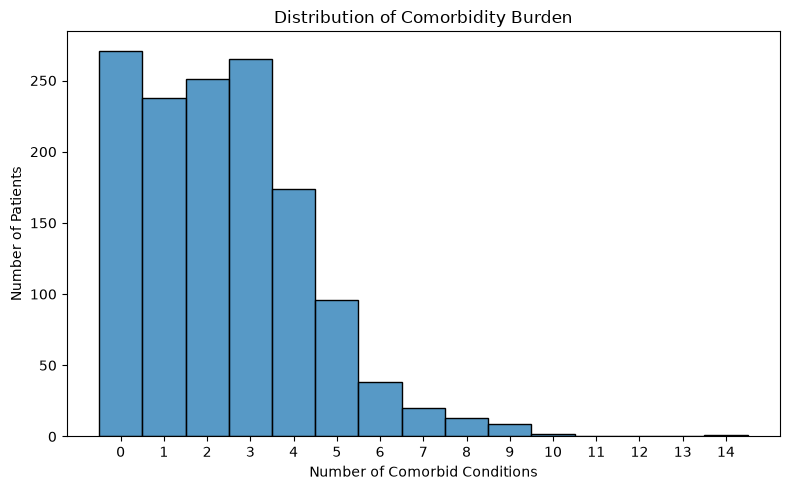

In [60]:
plt.figure(figsize=(8, 5))

sns.histplot(
    train_df["comorbidity_count"],
    discrete=True,
    bins=range(
        int(train_df["comorbidity_count"].min()),
        int(train_df["comorbidity_count"].max()) + 2
    )
)

plt.title("Distribution of Comorbidity Burden")
plt.xlabel("Number of Comorbid Conditions")
plt.ylabel("Number of Patients")

plt.xticks(
    range(
        int(train_df["comorbidity_count"].min()),
        int(train_df["comorbidity_count"].max()) + 1
    )
)

plt.tight_layout()
plt.show()

### 5.8 Comorbidity Burden and Post-index Healthcare Costs

To examine whether higher comorbidity burden is associated with increased healthcare costs, patients will be grouped according to the number of recorded comorbid conditions.

The groups are defined as 0, 1–2, 3–4, and 5 or more comorbidities. Mean and median post-index total healthcare costs will then be compared across these groups.

In [61]:
train_df["comorbidity_burden_group"] = pd.cut(
    train_df["comorbidity_count"],
    bins=[-1, 0, 2, 4, np.inf],
    labels=["0", "1-2", "3-4", "5+"]
)

comorbidity_cost_summary = train_df.groupby(
    "comorbidity_burden_group",
    observed=False
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

comorbidity_cost_summary.round(2)

,count,mean,median
comorbidity_burden_group,,,
0,271,4237.71,1607.37
1-2,489,4985.12,1966.64
3-4,439,5909.23,2681.37
5+,179,11447.68,5522.67


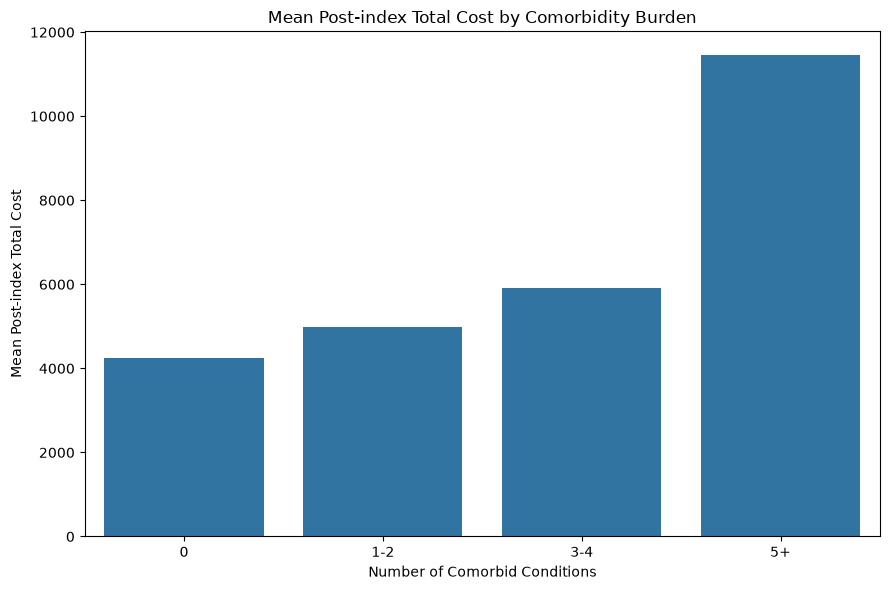

In [62]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=comorbidity_cost_summary.reset_index(),
    x="comorbidity_burden_group",
    y="mean"
)

plt.title("Mean Post-index Total Cost by Comorbidity Burden")
plt.xlabel("Number of Comorbid Conditions")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

### Comorbidity Burden and Post-index Cost — Interpretation

The analysis shows a clear positive association between comorbidity burden and mean post-index total healthcare costs.

Mean post-index cost increased progressively from 4,237.71 among patients with no recorded comorbidities to 4,985.12 among patients with 1–2 comorbidities and 5,909.23 among patients with 3–4 comorbidities.

Patients with five or more comorbidities had substantially higher mean post-index costs of 11,447.68, which was more than twice the mean cost observed among patients without recorded comorbidities.

The median post-index cost followed the same general pattern, increasing from 1,607.37 in the group with no comorbidities to 5,522.67 in the 5+ comorbidity group.

These findings suggest that a higher comorbidity burden is associated with higher post-index healthcare costs. However, this descriptive analysis does not establish a causal relationship.

In [63]:
train_df["comorbidity_burden_group"].value_counts().sort_index()

comorbidity_burden_group
0      271
1-2    489
3-4    439
5+     179
Name: count, dtype: int64

## 5.9 Medication Adherence Analysis

Medication adherence is assessed using the Proportion of Days Covered (PDC), a measure representing the proportion of days during the observation period for which a patient had medication coverage.

A PDC value of 0.80 or higher is commonly used as a threshold for adequate medication adherence in this analysis.

The analysis will examine the distribution of PDC, the proportion of patients meeting the 80% adherence threshold, and whether medication adherence is associated with post-index healthcare costs.

In [64]:
pdc_summary = train_df["pdc"].describe()

pdc_summary

count    1378.000000
mean        0.637333
std         0.285241
min         0.022222
25%         0.411111
50%         0.666667
75%         0.905556
max         1.000000
Name: pdc, dtype: float64

### 5.10 Medication Adherence Groups

Patients are categorized according to the 80% PDC threshold used in this analysis.

Patients with a PDC below 80% are classified as having lower medication adherence, while patients with a PDC of at least 80% are classified as having adequate adherence.

The distribution of these groups will be examined before comparing their healthcare costs.

In [65]:
pdc_group_summary = pd.DataFrame({
    "Patients": train_df["pdc_80_flag"].value_counts().sort_index(),
    "Percentage": (
        train_df["pdc_80_flag"].value_counts(normalize=True).sort_index() * 100
    ).round(1)
})

pdc_group_summary.index = [
    "PDC < 80%",
    "PDC ≥ 80%"
]

pdc_group_summary

,Patients,Percentage
PDC < 80%,836,60.7
PDC ≥ 80%,542,39.3


### Medication Adherence — Interpretation

The medication adherence analysis shows that 542 patients (39.3%) had a PDC of at least 80%, while 836 patients (60.7%) had a PDC below 80%.

Therefore, fewer than half of the patients in the study population met the 80% adherence threshold.

This indicates that lower medication adherence is relatively common within the analyzed population and provides an important basis for examining whether medication adherence is associated with differences in post-index healthcare costs.

#### 5.11 Medication Adherence and Post-index Healthcare Costs

To examine whether medication adherence is associated with healthcare costs, mean and median post-index total healthcare costs will be compared between patients below and above the 80% PDC threshold.

In [66]:
pdc_cost_summary = train_df.groupby(
    "pdc_80_flag"
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

pdc_cost_summary.index = [
    "PDC < 80%",
    "PDC ≥ 80%"
]

pdc_cost_summary.round(2)

,count,mean,median
PDC < 80%,836,6083.83,2286.80
PDC ≥ 80%,542,5799.53,2831.99


### Medication Adherence and Post-index Cost — Interpretation

The comparison of post-index total healthcare costs shows relatively similar mean costs between the two medication adherence groups.

Patients with PDC below 80% had a mean post-index cost of 6,083.83, compared with 5,799.53 among patients with PDC of at least 80%.

The median cost showed the opposite pattern, with 2,286.80 among patients with PDC below 80% and 2,831.99 among patients with PDC of at least 80%.

The difference between the mean and median patterns suggests that healthcare costs are highly variable and influenced by extreme observations. Therefore, the descriptive comparison alone does not provide sufficient evidence of a meaningful association between medication adherence and healthcare costs.

Further statistical analysis will be required to determine whether the observed differences are statistically significant.

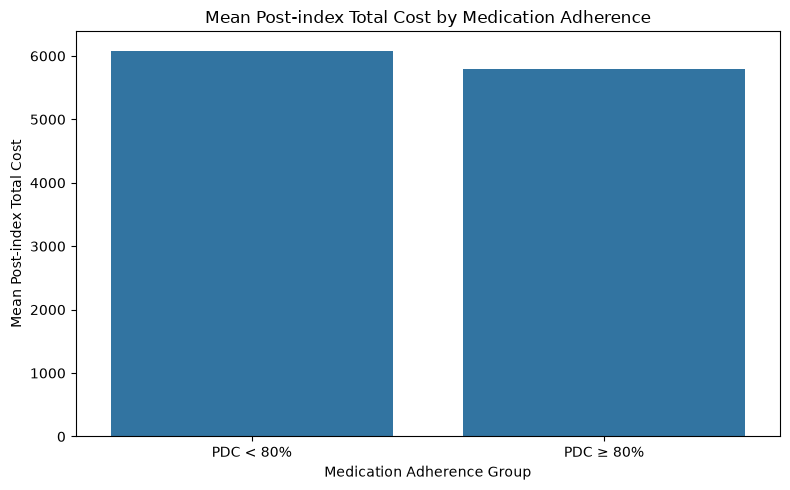

In [67]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=pdc_cost_summary.reset_index(),
    x=pdc_cost_summary.index,
    y="mean"
)

plt.title("Mean Post-index Total Cost by Medication Adherence")
plt.xlabel("Medication Adherence Group")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

### 5.12 PDC and Post-index Healthcare Cost

The binary 80% adherence threshold provides a useful categorical comparison, but it may hide variation within each adherence group.

Therefore, PDC will also be examined as a continuous measure in relation to post-index total healthcare cost. This analysis will help assess whether higher medication adherence is associated with a consistent change in healthcare costs across the full range of PDC values.

In [68]:
pdc_cost_correlation = train_df[
    ["pdc", "post_total_cost"]
].corr()

pdc_cost_correlation

,pdc,post_total_cost
pdc,1.000000,-0.000722
post_total_cost,-0.000722,1.000000


### PDC and Post-index Cost — Interpretation

The Pearson correlation between PDC and post-index total healthcare cost is -0.000722, indicating an essentially zero linear association between medication adherence and post-index total cost in this dataset.

This result suggests that higher medication adherence, when treated as a continuous measure, is not linearly associated with higher or lower post-index total healthcare costs.

The correlation should be interpreted cautiously because Pearson correlation captures only linear relationships and does not account for other patient characteristics or healthcare utilization factors.

Therefore, the relationship between medication adherence and healthcare costs should be examined further using statistical analysis and while accounting for potential confounding factors.

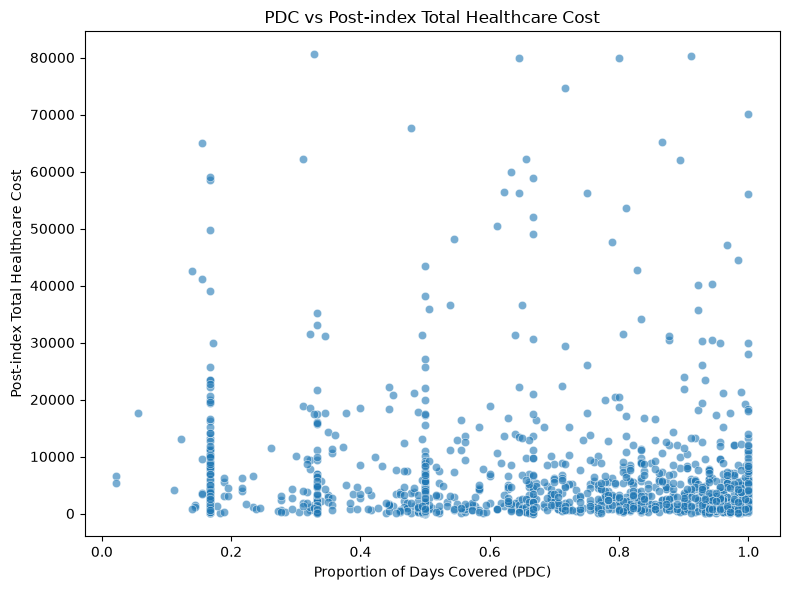

In [69]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=train_df,
    x="pdc",
    y="post_total_cost",
    alpha=0.6
)

plt.title("PDC vs Post-index Total Healthcare Cost")
plt.xlabel("Proportion of Days Covered (PDC)")
plt.ylabel("Post-index Total Healthcare Cost")

plt.tight_layout()
plt.show()

### PDC and Healthcare Cost — Final Interpretation

The continuous PDC analysis provides additional evidence that medication adherence is not strongly linearly associated with post-index total healthcare cost in this patient population.

The Pearson correlation was -0.000722, indicating an essentially negligible linear relationship between PDC and post-index total cost. The scatter plot also shows no clear linear pattern between the two variables.

The comparison based on the 80% adherence threshold showed relatively similar mean costs between the two groups, with a mean cost of 6,083.83 for patients with PDC below 80% and 5,799.53 for patients with PDC of at least 80%.

These descriptive findings suggest that medication adherence alone does not appear to be a strong linear indicator of post-index total healthcare cost in this dataset. However, this does not exclude more complex relationships or effects that may become apparent after accounting for patient characteristics, comorbidity burden, and healthcare utilization.

## 6. Healthcare Utilization and Post-index Cost

The next stage examines the relationship between healthcare utilization and post-index total healthcare costs.

The analysis focuses on inpatient admissions, emergency room visits, outpatient visits, length of stay, and prescription utilization.

The objective is to identify which utilization measures show the strongest associations with post-index healthcare costs and may therefore represent important indicators of higher healthcare expenditure.

In [70]:
utilization_cols = [
    "num_ip_post",
    "total_los_post",
    "num_op_post",
    "num_er_post",
    "num_ndc_post",
    "num_gpi6_post"
]

utilization_cost_corr = train_df[
    utilization_cols + ["post_total_cost"]
].corr()["post_total_cost"].drop("post_total_cost")

utilization_cost_corr.sort_values(
    key=abs,
    ascending=False
)

num_ip_post       0.600088
num_op_post       0.550763
total_los_post    0.502642
num_gpi6_post     0.403012
num_ndc_post      0.348279
num_er_post       0.312605
Name: post_total_cost, dtype: float64

### Healthcare Utilization and Post-index Cost — Correlation Analysis

The correlation analysis shows positive associations between all examined healthcare utilization measures and post-index total healthcare cost.

Inpatient admissions had the strongest correlation with post-index total cost (r = 0.600), followed by outpatient visits (r = 0.551) and total length of stay (r = 0.503).

Prescription utilization measures also showed positive associations, with GPI6 utilization (r = 0.403) and NDC utilization (r = 0.348).

Emergency room visits showed the weakest, although still positive, association among the examined utilization measures (r = 0.313).

Overall, inpatient admissions, outpatient visits, and length of stay appear to be the utilization measures most strongly associated with post-index healthcare costs.

These findings represent associations rather than causal relationships and will be examined further using statistical analysis.

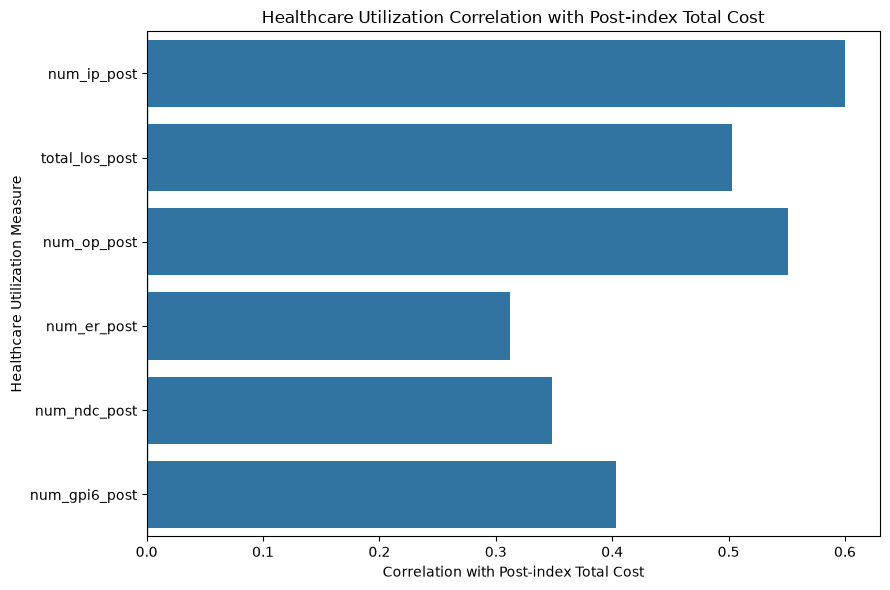

In [71]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=utilization_cost_corr.values,
    y=utilization_cost_corr.index
)

plt.title("Healthcare Utilization Correlation with Post-index Total Cost")
plt.xlabel("Correlation with Post-index Total Cost")
plt.ylabel("Healthcare Utilization Measure")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

### 6.1 Inpatient Admissions and Post-index Cost

Inpatient admissions showed the strongest correlation with post-index total healthcare cost among the utilization measures examined.

To further explore this relationship, post-index total healthcare costs will be compared across patients with different numbers of inpatient admissions.

In [72]:
ip_cost_summary = train_df.groupby(
    "num_ip_post"
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

ip_cost_summary.round(2)

,count,mean,median
num_ip_post,,,
0,1275,4270.16,2253.74
1,85,24021.81,17721.27
2,14,38488.17,33816.99
3,4,51072.94,54323.98


### Inpatient Admissions and Post-index Cost — Interpretation

Post-index total healthcare costs increased substantially with the number of inpatient admissions.

Patients with no inpatient admissions had a mean post-index cost of 4,270.16, compared with 24,021.81 among patients with one admission. The mean cost increased further to 38,488.17 for patients with two admissions and 51,072.94 for patients with three admissions.

The median costs followed a similar pattern, increasing from 2,253.74 among patients with no inpatient admissions to 54,323.98 among patients with three admissions.

These findings indicate a strong positive association between inpatient utilization and post-index healthcare costs. However, the groups with two and three admissions contain relatively few patients (14 and 4, respectively). Therefore, the estimates for these groups should be interpreted cautiously and do not by themselves establish a causal relationship.

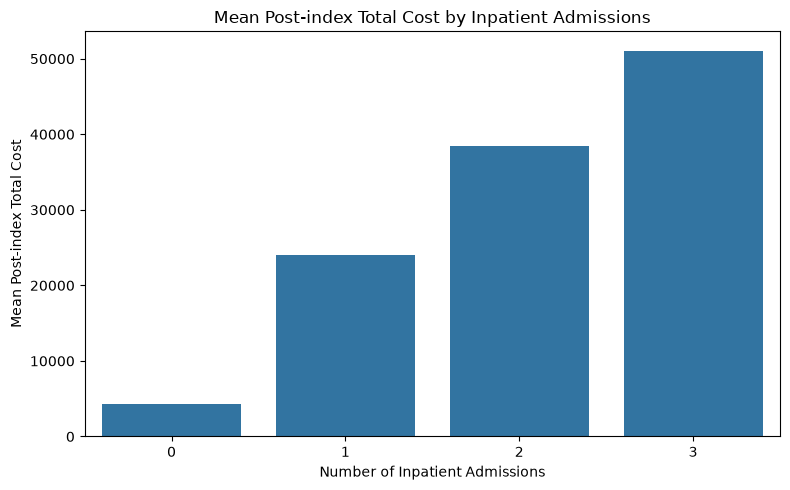

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=ip_cost_summary.reset_index(),
    x="num_ip_post",
    y="mean"
)

plt.title("Mean Post-index Total Cost by Inpatient Admissions")
plt.xlabel("Number of Inpatient Admissions")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

### 6.2 Outpatient Visits and Post-index Cost

Outpatient visits showed the second-strongest correlation with post-index total healthcare cost.

To further examine this relationship, post-index total healthcare costs will be compared across patients with different levels of outpatient utilization.

In [74]:
op_cost_summary = train_df.groupby(
    "num_op_post"
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

op_cost_summary.round(2)

,count,mean,median
num_op_post,,,
0,69,1022.33,251.55
1,129,1243.28,447.40
2,141,1526.27,866.98
3,160,2642.92,1191.88
4,125,3633.20,2050.54
5,147,3598.35,2354.08
6,96,4560.55,2816.25
7,78,6313.30,3188.52
8,47,5892.07,4011.07


### Outpatient Utilization Groups

Because outpatient visit counts are highly dispersed and some higher utilization levels contain very few patients, individual visit counts are grouped into broader utilization categories.

The groups are defined as 0, 1–5, 6–10, 11–20, and 21 or more outpatient visits. This grouping improves interpretability and reduces the influence of very small patient groups when comparing post-index healthcare costs.

In [75]:
train_df["op_utilization_group"] = pd.cut(
    train_df["num_op_post"],
    bins=[-1, 0, 5, 10, 20, np.inf],
    labels=["0", "1-5", "6-10", "11-20", "21+"]
)

op_group_cost_summary = train_df.groupby(
    "op_utilization_group",
    observed=False
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

op_group_cost_summary.round(2)

,count,mean,median
op_utilization_group,,,
0,69,1022.33,251.55
1-5,702,2537.84,1302.71
6-10,333,6012.18,3469.57
11-20,196,13544.50,8766.82
21+,78,22058.36,15135.57


### Outpatient Visits and Post-index Cost — Interpretation

Post-index total healthcare costs increased substantially across higher outpatient utilization groups.

Patients with no outpatient visits had a mean post-index cost of 1,022.33. Mean cost increased to 2,537.84 among patients with 1–5 visits, 6,012.18 among those with 6–10 visits, and 13,544.50 among those with 11–20 visits.

Patients with 21 or more outpatient visits had the highest mean post-index cost at 22,058.36. The median cost followed the same overall pattern, increasing from 251.55 among patients with no outpatient visits to 15,135.57 among patients with 21 or more visits.

Overall, the results show a strong positive association between outpatient utilization and post-index healthcare costs. Higher outpatient utilization is consistently associated with substantially higher healthcare expenditure.

These findings represent an association and should not be interpreted as evidence that outpatient visits independently cause higher healthcare costs.

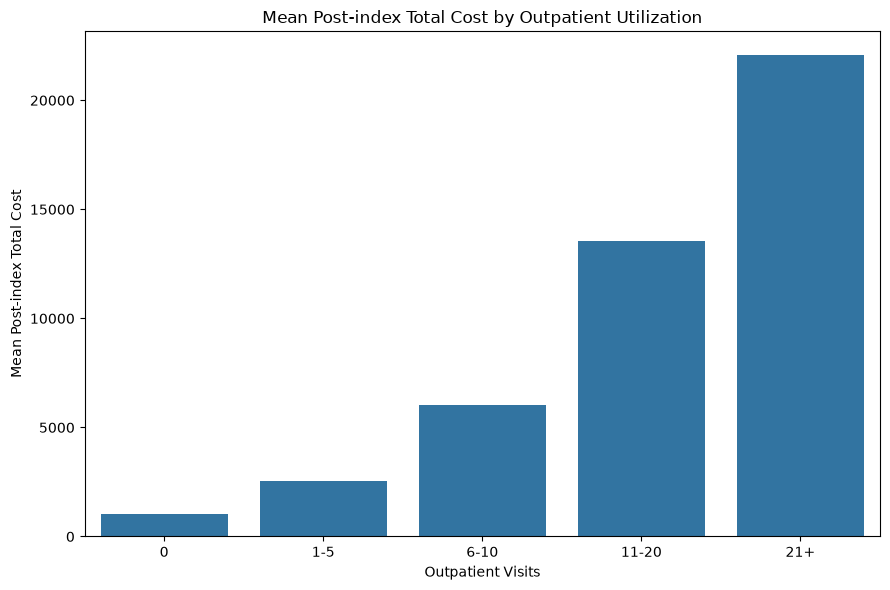

In [76]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=op_group_cost_summary.reset_index(),
    x="op_utilization_group",
    y="mean"
)

plt.title("Mean Post-index Total Cost by Outpatient Utilization")
plt.xlabel("Outpatient Visits")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

### 6.3 Length of Stay and Post-index Cost

Total length of stay was positively associated with post-index total healthcare cost (r = 0.503).

To further examine this relationship, post-index total healthcare costs will be compared across patients with different lengths of stay.

In [77]:
los_cost_summary = train_df.groupby(
    "total_los_post"
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

los_cost_summary.round(2)

,count,mean,median
total_los_post,,,
0,1275,4270.16,2253.74
2,24,21885.88,18918.13
3,23,19232.60,13233.10
4,18,25370.84,17612.21
5,8,21545.40,18202.21
6,3,31715.81,22782.05
7,3,28217.57,31106.81
8,7,42449.89,42676.46
9,5,30779.15,17641.93


### Length of Stay Groups

Because individual length-of-stay values above five days contain relatively small patient groups, length of stay is grouped into broader categories.

The groups are defined as 0 days, 1–5 days, 6–10 days, and 11 or more days. This grouping improves interpretability and reduces the influence of very small groups when comparing post-index healthcare costs.

In [78]:
train_df["los_group"] = pd.cut(
    train_df["total_los_post"],
    bins=[-1, 0, 5, 10, np.inf],
    labels=["0 days", "1-5 days", "6-10 days", "11+ days"]
)

los_group_cost_summary = train_df.groupby(
    "los_group",
    observed=False
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

los_group_cost_summary.round(2)

,count,mean,median
los_group,,,
0 days,1275,4270.16,2253.74
1-5 days,73,21871.91,17168.86
6-10 days,20,34865.27,33816.99
11+ days,10,49102.52,54323.98


### Length of Stay and Post-index Cost — Interpretation

Post-index total healthcare costs increased substantially across higher length-of-stay groups.

Patients with no recorded inpatient length of stay had a mean post-index cost of 4,270.16. This increased to 21,871.91 among patients with 1–5 days of stay, 34,865.27 among those with 6–10 days, and 49,102.52 among patients with 11 or more days.

The median cost followed the same overall pattern, increasing from 2,253.74 among patients with no recorded length of stay to 54,323.98 among patients with 11 or more days.

These findings show a strong positive association between length of stay and post-index healthcare costs. Patients with longer stays tend to have substantially higher healthcare expenditure.

However, the groups with 6–10 days and 11+ days contain relatively few patients (20 and 10, respectively). Therefore, the estimates for these groups should be interpreted cautiously and should not be considered evidence of a causal relationship.

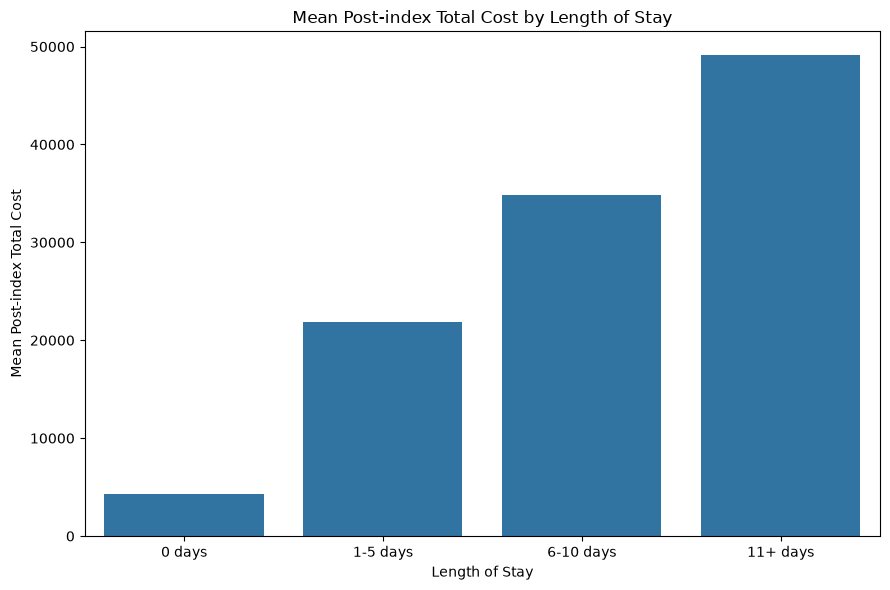

In [79]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=los_group_cost_summary.reset_index(),
    x="los_group",
    y="mean"
)

plt.title("Mean Post-index Total Cost by Length of Stay")
plt.xlabel("Length of Stay")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

### 6.4 Emergency Room Visits and Post-index Cost

Emergency room visits showed a positive association with post-index total healthcare cost (r = 0.313).

To further examine this relationship, post-index total healthcare costs will be compared across patients with different levels of emergency room utilization.

In [80]:
er_cost_summary = train_df.groupby(
    "num_er_post"
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

er_cost_summary.round(2)

,count,mean,median
num_er_post,,,
0,1197,4658.18,2113.40
1,121,13021.25,5736.88
2,38,16397.77,9040.17
3,13,22511.25,17581.04
4,6,19134.51,18562.19
5,1,14293.76,14293.76
6,2,16577.33,16577.33


### Emergency Room Visits and Post-index Cost — Interpretation

Post-index total healthcare costs were generally higher among patients with emergency room utilization compared with patients with no emergency room visits.

Patients with no ER visits had a mean post-index cost of 4,658.18, compared with 13,021.25 among patients with one ER visit. The mean cost increased further to 16,397.77 for two visits and 22,511.25 for three visits.

The median cost also increased from 2,113.40 among patients with no ER visits to 17,581.04 among patients with three ER visits.

Overall, the results indicate a positive association between emergency room utilization and post-index healthcare costs. However, the categories with four or more ER visits contain very few patients, making their individual estimates unstable.

Therefore, the observed pattern should be interpreted as an association rather than evidence of a causal effect.

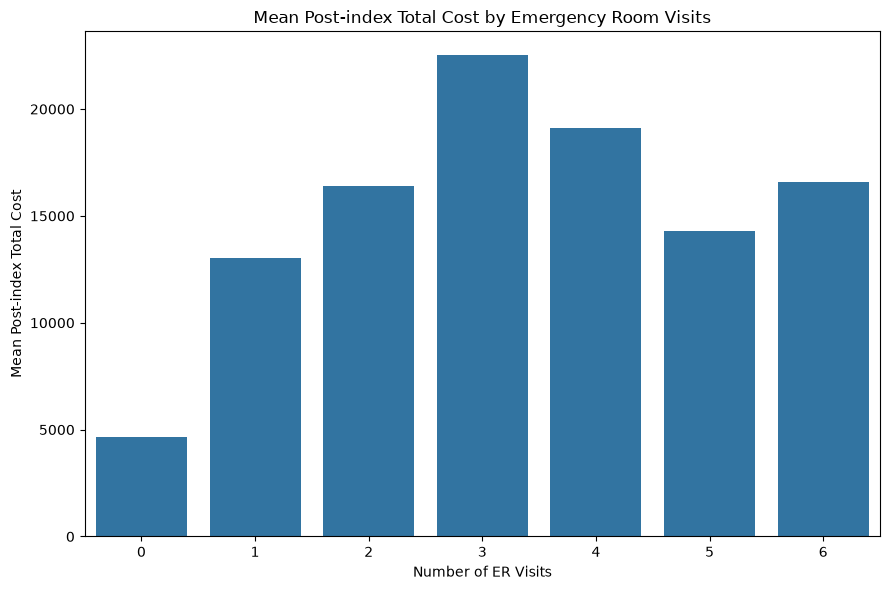

In [81]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=er_cost_summary.reset_index(),
    x="num_er_post",
    y="mean"
)

plt.title("Mean Post-index Total Cost by Emergency Room Visits")
plt.xlabel("Number of ER Visits")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

### 6.5 NDC Utilization and Post-index Cost

NDC utilization showed a positive association with post-index total healthcare cost (r = 0.348).

To further examine this relationship, post-index total healthcare costs will be compared across different levels of NDC utilization.

In [82]:
ndc_cost_summary = train_df.groupby(
    "num_ndc_post"
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

ndc_cost_summary.round(2)

,count,mean,median
num_ndc_post,,,
1,17,2281.52,473.82
2,31,1535.01,512.74
3,34,1403.25,556.69
4,44,1866.23,497.70
5,40,2896.30,868.36
...,...,...,...
77,1,6152.00,6152.00
78,1,11785.26,11785.26
83,2,11440.06,11440.06


### NDC Utilization Groups

NDC utilization contains many distinct utilization levels, with several higher levels represented by very small patient groups.

To improve interpretability and reduce the influence of sparse categories, NDC utilization is grouped into broader categories: 1–10, 11–20, 21–40, and 41+ utilization events.

In [83]:
train_df["ndc_utilization_group"] = pd.cut(
    train_df["num_ndc_post"],
    bins=[0, 10, 20, 40, np.inf],
    labels=["1-10", "11-20", "21-40", "41+"]
)

ndc_group_cost_summary = train_df.groupby(
    "ndc_utilization_group",
    observed=False
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

ndc_group_cost_summary.round(2)

,count,mean,median
ndc_utilization_group,,,
1-10,455,2995.91,1066.09
11-20,477,5054.28,2348.28
21-40,372,8640.02,4784.44
41+,74,16774.56,8628.76


### NDC Utilization and Post-index Cost — Interpretation

Post-index total healthcare costs increased consistently across higher NDC utilization groups.

Patients with 1–10 NDC utilization events had a mean post-index cost of 2,995.91. This increased to 5,054.28 among patients with 11–20 events, 8,640.02 among patients with 21–40 events, and 16,774.56 among patients with 41 or more events.

The median cost followed the same overall pattern, increasing from 1,066.09 in the lowest utilization group to 8,628.76 among patients with 41 or more NDC utilization events.

Overall, the results indicate a clear positive association between NDC utilization and post-index total healthcare costs. Higher prescription-related utilization is associated with substantially higher healthcare expenditure.

The highest utilization group contains fewer patients (n = 74) than the other groups, so this estimate should be interpreted with some caution. These findings represent associations and do not establish a causal relationship.

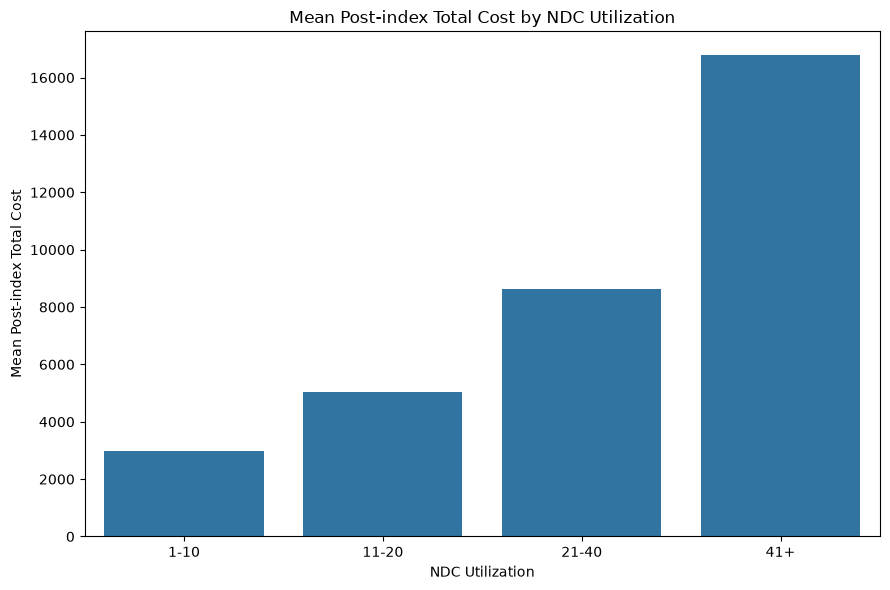

In [84]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=ndc_group_cost_summary.reset_index(),
    x="ndc_utilization_group",
    y="mean"
)

plt.title("Mean Post-index Total Cost by NDC Utilization")
plt.xlabel("NDC Utilization")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

### 6.6 GPI6 Utilization and Post-index Cost

GPI6 utilization showed a positive association with post-index total healthcare cost (r = 0.403).

To further examine this relationship, post-index total healthcare costs will be compared across different levels of GPI6 utilization.

In [85]:
gpi6_cost_summary = train_df.groupby(
    "num_gpi6_post"
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

gpi6_cost_summary.round(2)

,count,mean,median
num_gpi6_post,,,
1,47,1388.36,302.12
2,77,1318.99,676.40
3,123,2423.11,992.48
4,157,2923.27,1272.81
5,172,4410.80,1743.97
6,163,4677.34,2455.80
7,134,3988.27,2673.91
8,118,7578.20,4624.78
9,86,7557.84,3342.03


### GPI6 Utilization Groups

GPI6 utilization contains multiple individual utilization levels, with higher levels represented by progressively smaller patient groups.

To improve interpretability and reduce the influence of sparse categories, GPI6 utilization is grouped into four broader categories: 1–5, 6–10, 11–15, and 16 or more utilization events.

In [86]:
train_df["gpi6_utilization_group"] = pd.cut(
    train_df["num_gpi6_post"],
    bins=[0, 5, 10, 15, np.inf],
    labels=["1-5", "6-10", "11-15", "16+"]
)

gpi6_group_cost_summary = train_df.groupby(
    "gpi6_utilization_group",
    observed=False
)["post_total_cost"].agg(
    ["count", "mean", "median"]
)

gpi6_group_cost_summary.round(2)

,count,mean,median
gpi6_utilization_group,,,
1-5,576,2920.95,1126.93
6-10,563,6377.42,3106.25
11-15,178,9061.89,6251.56
16+,61,22023.89,11833.20


### GPI6 Utilization and Post-index Cost — Interpretation

Post-index total healthcare costs increased substantially across higher GPI6 utilization groups.

Patients with 1–5 GPI6 utilization events had a mean post-index cost of 2,920.95. Mean cost increased to 6,377.42 among patients with 6–10 events, 9,061.89 among those with 11–15 events, and 22,023.89 among patients with 16 or more events.

The median cost followed the same overall pattern, increasing from 1,126.93 in the lowest utilization group to 11,833.20 among patients with 16 or more GPI6 utilization events.

Overall, the results indicate a clear positive association between GPI6 utilization and post-index total healthcare costs. Higher GPI6 utilization is associated with substantially higher healthcare expenditure.

The highest utilization group contains fewer patients (n = 61) than the other groups, so its estimate should be interpreted with some caution. These findings represent associations and do not establish a causal relationship.

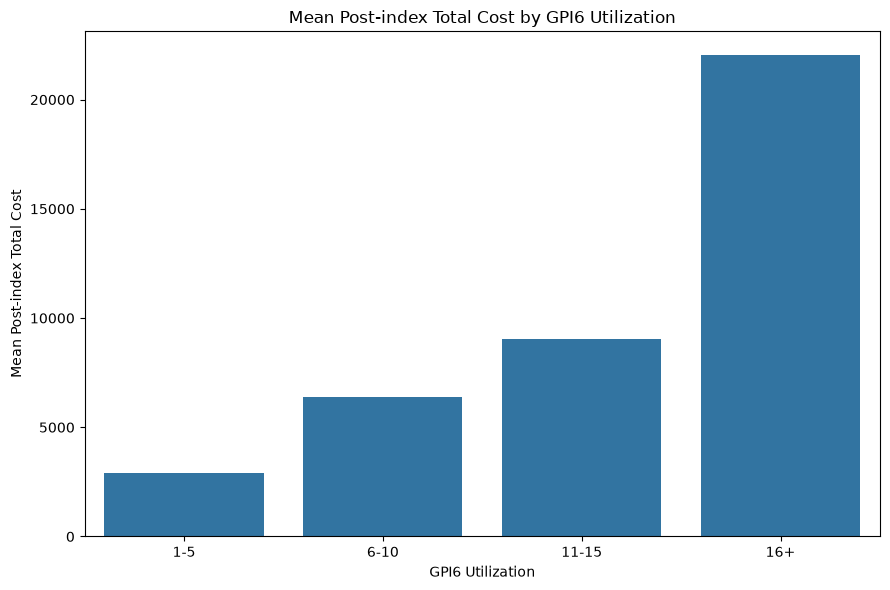

In [87]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=gpi6_group_cost_summary.reset_index(),
    x="gpi6_utilization_group",
    y="mean"
)

plt.title("Mean Post-index Total Cost by GPI6 Utilization")
plt.xlabel("GPI6 Utilization")
plt.ylabel("Mean Post-index Total Cost")

plt.tight_layout()
plt.show()

## 6.7 Summary — Healthcare Utilization and Post-index Cost

The utilization analysis consistently showed positive associations between healthcare service use and post-index total healthcare costs.

Among the examined utilization measures, inpatient admissions showed the strongest correlation with post-index total cost (r = 0.600), followed by outpatient visits (r = 0.551) and total length of stay (r = 0.503). GPI6 utilization (r = 0.403), NDC utilization (r = 0.348), and emergency room visits (r = 0.313) also showed positive associations.

The grouped analyses supported these correlation findings. Higher levels of inpatient admissions, outpatient visits, length of stay, NDC utilization, and GPI6 utilization were generally associated with substantially higher post-index healthcare costs.

The strongest cost gradients were observed for inpatient admissions, outpatient visits, and length of stay. For example, mean post-index cost increased from 4,270.16 among patients with no inpatient admissions to 51,072.94 among patients with three admissions. Similarly, mean cost increased from 1,022.33 among patients with no outpatient visits to 22,058.36 among patients with 21 or more visits.

Overall, the findings suggest that healthcare utilization is strongly associated with post-index healthcare expenditure, particularly inpatient and outpatient utilization and length of stay.

These results are exploratory and describe associations rather than causal relationships. Several high-utilization groups contain relatively few patients, so their individual cost estimates should be interpreted cautiously.

The next stage of the analysis will investigate these relationships using statistical methods while accounting for other patient characteristics and clinical factors.

# 7. Statistical Analysis

The exploratory analysis identified several important associations between patient characteristics, healthcare utilization, medication adherence, and post-index healthcare costs.

The statistical analysis phase aims to formally evaluate selected relationships identified during EDA and determine whether observed differences between patient groups are statistically significant.

The analysis will focus on group comparisons and associations involving post-index healthcare costs, with particular attention to medication adherence, healthcare utilization, and comorbidity burden.

Statistical significance will be evaluated using appropriate hypothesis tests, while effect sizes and practical relevance will also be considered. Statistical significance alone will not be interpreted as evidence of causality.

In [88]:
pdc_cost_groups = train_df.groupby(
    "pdc_80_flag"
)["post_total_cost"]

pdc_cost_groups.agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
pdc_80_flag,,,,
0,836,6083.83,2286.80,10833.74
1,542,5799.53,2831.99,9749.23


In [89]:
import sys

print(sys.executable)

/home/florenckaraj/patient_healthcare_analytics/healthcare_analytics_env/bin/python


In [90]:
import scipy
print("SciPy version", scipy.__version__)

SciPy version 1.18.0


### 7.1 PDC Adherence and Post-index Cost — Hypothesis Test

The exploratory analysis showed a difference in post-index total healthcare costs between patients with PDC < 80% and those with PDC ≥ 80%.

To formally evaluate whether the difference in mean cost is statistically significant, Welch's independent samples t-test will be used.

**Null hypothesis (H₀):** The mean post-index total cost is equal between the two PDC groups.

**Alternative hypothesis (H₁):** The mean post-index total cost differs between the two PDC groups.

A significance level of α = 0.05 will be used.

In [91]:
from scipy.stats import ttest_ind

pdc_low = train_df.loc[
    train_df["pdc_80_flag"] == 0,
    "post_total_cost"
].dropna()

pdc_high = train_df.loc[
    train_df["pdc_80_flag"] == 1,
    "post_total_cost"
].dropna()

t_stat, p_value = ttest_ind(
    pdc_low,
    pdc_high,
    equal_var=False
)

print("Welch's t-statistic:", t_stat)
print("p-value:", p_value)

Welch's t-statistic: 0.5059415242543641
p-value: 0.6129876785840188


In [92]:
print(train_df.shape)

(1378, 103)


In [93]:
print(train_df[["pdc_80_flag", "post_total_cost"]].head())

   pdc_80_flag  post_total_cost
0            0       290.390082
1            1       667.606022
2            0      1181.315989
3            0         8.100969
4            1       263.571819


### 7.1.1 Welch's t-test — Interpretation

Welch's independent samples t-test was used to compare mean post-index total healthcare costs between patients with PDC < 80% and patients with PDC ≥ 80%.

The test produced a t-statistic of 0.506 and a p-value of 0.613.

Because the p-value is greater than the significance level of α = 0.05, the null hypothesis is not rejected.

Therefore, the analysis does not provide sufficient statistical evidence of a difference in mean post-index total healthcare costs between the two PDC adherence groups.

Although the descriptive analysis showed slightly different mean costs between the groups, the observed difference is not statistically significant based on this test.

This result highlights the importance of combining descriptive analysis with statistical hypothesis testing. A visible difference in group means does not necessarily imply a statistically significant difference.

### 7.2 PDC Groups — Mean Cost Difference

Although the Welch's t-test did not identify a statistically significant difference between the two PDC groups, the magnitude of the observed difference in mean post-index cost can still be examined.

The absolute and relative difference in mean cost will be calculated to assess the practical magnitude of the observed variation.

In [94]:
mean_pdc_low = pdc_low.mean()
mean_pdc_high = pdc_high.mean()

absolute_difference = mean_pdc_high - mean_pdc_low
relative_difference = (
    absolute_difference / mean_pdc_low
) * 100

print("Mean cost - PDC < 80%:", round(mean_pdc_low, 2))
print("Mean cost - PDC ≥ 80%:", round(mean_pdc_high, 2))
print("Absolute difference:", round(absolute_difference, 2))
print("Relative difference (%):", round(relative_difference, 2))

Mean cost - PDC < 80%: 6083.83
Mean cost - PDC ≥ 80%: 5799.53
Absolute difference: -284.3
Relative difference (%): -4.67


### 7.2.1 Mean Cost Difference — Interpretation

The mean post-index total healthcare cost was 6,083.83 for patients with PDC < 80% and 5,799.53 for patients with PDC ≥ 80%.

This corresponds to an absolute difference of -284.30 and a relative difference of approximately -4.67%, indicating that the high-adherence group had a slightly lower mean post-index cost.

However, the Welch's t-test produced a p-value of 0.613, meaning that this observed difference was not statistically significant at the 0.05 significance level.

Therefore, the observed 4.67% difference should not be interpreted as evidence that higher medication adherence is associated with lower healthcare costs in this sample.

This comparison demonstrates why practical differences should be evaluated together with statistical significance rather than interpreted independently.

### 7.3 Healthcare Utilization and Post-index Cost

The exploratory analysis showed that several post-index healthcare utilization measures were positively associated with total post-index healthcare costs.

To formally assess these relationships, statistical significance will be evaluated for selected utilization variables, with particular attention to inpatient admissions, outpatient visits, emergency room visits, and total length of stay.

The analysis will focus on the strength and statistical significance of these associations and will not be interpreted as evidence of causality.

In [95]:
from scipy.stats import pearsonr

ip_data = train_df[
    ["num_ip_post", "post_total_cost"]
].dropna()

r_ip, p_ip = pearsonr(
    ip_data["num_ip_post"],
    ip_data["post_total_cost"]
)

print("Pearson correlation (r):", r_ip)
print("p-value:", p_ip)

Pearson correlation (r): 0.6000876981135647
p-value: 1.4337104863956225e-135


### 7.3.1 Inpatient Admissions and Post-index Cost — Interpretation

Pearson correlation analysis showed a positive correlation between post-index inpatient admissions and total post-index healthcare costs (r = 0.600).

The association was statistically significant (p < 0.001), indicating that higher inpatient utilization is significantly associated with higher post-index healthcare costs in this sample.

The strength and direction of the correlation are consistent with the exploratory analysis, which also showed that inpatient utilization was one of the strongest utilization-related factors associated with post-index cost.

However, this result represents an association rather than a causal relationship. Higher inpatient utilization may reflect greater healthcare needs or patient complexity, which can also contribute to higher costs.

In [96]:
op_data = train_df[
    ["num_op_post", "post_total_cost"]
].dropna()

r_op, p_op = pearsonr(
    op_data["num_op_post"],
    op_data["post_total_cost"]
)

print("Pearson correlation (r):", r_op)
print("p-value:", p_op)

Pearson correlation (r): 0.5507627150161626
p-value: 3.8852060740391694e-110


### 7.3.2 Outpatient Visits and Post-index Cost — Interpretation

Pearson correlation analysis showed a positive correlation between post-index outpatient visits and total post-index healthcare costs (r = 0.551).

The association was statistically significant (p < 0.001), indicating that higher outpatient utilization is significantly associated with higher post-index healthcare costs in this sample.

The correlation was slightly weaker than the association observed for inpatient admissions (r = 0.600), but it still represents a moderate-to-strong positive relationship.

As with the inpatient utilization analysis, this finding represents an association rather than evidence of causality. Higher outpatient utilization may be related to greater healthcare needs or patient complexity, which may also contribute to higher healthcare costs.

In [97]:
er_data = train_df[
    ["num_er_post", "post_total_cost"]
].dropna()

r_er, p_er = pearsonr(
    er_data["num_er_post"],
    er_data["post_total_cost"]
)

print("Pearson correlation (r):", r_er)
print("p-value:", p_er)

Pearson correlation (r): 0.31260453788072773
p-value: 1.2852884177770187e-32


### 7.3.3 Emergency Room Visits and Post-index Cost — Interpretation

Pearson correlation analysis showed a positive correlation between post-index emergency room visits and total post-index healthcare costs (r = 0.313).

The association was statistically significant (p < 0.001), indicating that higher emergency room utilization is significantly associated with higher post-index healthcare costs in this sample.

However, the correlation was weaker than the associations observed for inpatient admissions (r = 0.600) and outpatient visits (r = 0.551).

This finding suggests that emergency room utilization is related to post-index healthcare costs, although the relationship is less pronounced than for inpatient and outpatient utilization.

As with the previous analyses, this result represents an association and does not establish a causal relationship.

In [98]:
los_data = train_df[
    ["total_los_post", "post_total_cost"]
].dropna()

r_los, p_los = pearsonr(
    los_data["total_los_post"],
    los_data["post_total_cost"]
)

print("Pearson correlation (r):", r_los)
print("p-value:", p_los)


Pearson correlation (r): 0.5026419031418399
p-value: 4.124310154255428e-89


### 7.3.4 Total Length of Stay and Post-index Cost — Interpretation

Pearson correlation analysis showed a positive correlation between total post-index length of stay and total post-index healthcare costs (r = 0.503).

The association was statistically significant (p < 0.001), indicating that longer total length of stay is significantly associated with higher post-index healthcare costs in this sample.

The strength of the relationship was moderate to strong and was comparable to the association observed for outpatient utilization (r = 0.551).

Overall, the results indicate that inpatient admissions, outpatient visits, emergency room visits, and length of stay are all significantly associated with post-index healthcare costs, with inpatient utilization showing the strongest correlation among the selected utilization measures.

These findings represent associations rather than causal relationships. Higher utilization and longer stays may reflect greater patient complexity or healthcare needs, which can also contribute to higher costs.

### 7.4 Comorbidity Burden and Post-index Cost

The exploratory analysis showed that patients with a higher comorbidity burden tended to have higher post-index healthcare costs.

To formally evaluate this relationship, Pearson correlation will be used to assess the association between the number of recorded comorbidities and total post-index healthcare costs.

The analysis will focus on the strength and statistical significance of the association and will not be interpreted as evidence of causality.

In [99]:
comorbidity_data = train_df[
    ["comorbidity_count", "post_total_cost"]
].dropna()

r_comorbidity, p_comorbidity = pearsonr(
    comorbidity_data["comorbidity_count"],
    comorbidity_data["post_total_cost"]
)

print("Pearson correlation (r):", r_comorbidity)
print("p-value:", p_comorbidity)

Pearson correlation (r): 0.23084083091230329
p-value: 3.9982855570065895e-18


### 7.4.1 Comorbidity Burden and Post-index Cost — Interpretation

Pearson correlation analysis showed a positive correlation between comorbidity count and total post-index healthcare costs (r = 0.231).

The association was statistically significant (p < 0.001), indicating that a higher number of recorded comorbidities is significantly associated with higher post-index healthcare costs in this sample.

However, the correlation was relatively weak compared with the utilization-related variables examined previously. This suggests that although comorbidity burden is statistically associated with cost, the number of comorbidities alone does not explain a large proportion of the variation in post-index healthcare costs.

The finding is consistent with the exploratory analysis, where patients with higher comorbidity burden showed higher average and median costs.

As with the previous analyses, this association should not be interpreted as evidence of causality.

### 7.5 Statistical Results Summary

The statistical analysis confirmed several significant associations between post-index healthcare utilization, comorbidity burden, medication adherence, and total post-index healthcare costs.

The strongest observed correlation was between inpatient admissions and post-index total cost, followed by outpatient visits and total length of stay. Emergency room utilization and comorbidity burden also showed statistically significant positive associations, although the strength of these relationships was lower.

In contrast, the comparison of post-index costs between patients with PDC < 80% and PDC ≥ 80% did not show a statistically significant difference in mean cost.

Overall, the results suggest that healthcare utilization measures are more strongly associated with post-index healthcare costs than medication adherence status or comorbidity count alone.

These findings represent statistical associations within the analyzed sample and should not be interpreted as causal relationships.

In [100]:
statistical_summary = pd.DataFrame({
    "Analysis": [
        "PDC <80% vs PDC ≥80%",
        "Inpatient admissions",
        "Outpatient visits",
        "Emergency room visits",
        "Total length of stay",
        "Comorbidity count"
    ],
    "Measure": [
        "Welch's t-test",
        "Pearson correlation",
        "Pearson correlation",
        "Pearson correlation",
        "Pearson correlation",
        "Pearson correlation"
    ],
    "Statistic": [
        t_stat,
        r_ip,
        r_op,
        r_er,
        r_los,
        r_comorbidity
    ],
    "p_value": [
        p_value,
        p_ip,
        p_op,
        p_er,
        p_los,
        p_comorbidity
    ]
})

statistical_summary.round(4)

,Analysis,Measure,Statistic,p_value
0,PDC <80% vs PDC ≥80%,Welch's t-test,0.5059,0.613
1,Inpatient admissions,Pearson correlation,0.6001,0.000
2,Outpatient visits,Pearson correlation,0.5508,0.000
3,Emergency room visits,Pearson correlation,0.3126,0.000
4,Total length of stay,Pearson correlation,0.5026,0.000
5,Comorbidity count,Pearson correlation,0.2308,0.000


### 7.5.1 Statistical Results — Interpretation

The statistical analysis identified statistically significant positive associations between all four healthcare utilization measures and post-index total healthcare costs.

Inpatient admissions showed the strongest association with post-index cost (r = 0.600, p < 0.001), followed by outpatient visits (r = 0.551, p < 0.001) and total length of stay (r = 0.503, p < 0.001). Emergency room visits also showed a statistically significant positive association, although the relationship was weaker (r = 0.313, p < 0.001).

Comorbidity count was also positively associated with post-index cost (r = 0.231, p < 0.001), but the relationship was considerably weaker than the utilization-related associations.

The comparison of mean post-index costs between patients with PDC < 80% and PDC ≥ 80% did not show a statistically significant difference (Welch's t-test, p = 0.613).

Overall, the statistical analysis suggests that healthcare utilization measures are more strongly associated with post-index healthcare costs than medication adherence status or comorbidity count alone.

These findings describe associations within the analyzed sample and should not be interpreted as evidence of causal relationships.

### 7.6 Multivariable Analysis

The previous statistical analyses evaluated the relationship between individual healthcare utilization and patient characteristics and post-index healthcare costs.

A multivariable analysis will now be performed to evaluate whether selected utilization and patient-related factors remain associated with post-index total healthcare costs when considered simultaneously.

The model will include healthcare utilization, comorbidity burden, and medication adherence variables identified as relevant during the exploratory and statistical analyses.

The results will be interpreted as adjusted associations rather than causal effects.

In [101]:
regression_vars = [
    "post_total_cost",
    "num_ip_post",
    "num_op_post",
    "num_er_post",
    "total_los_post",
    "comorbidity_count",
    "pdc_80_flag"
]

regression_data = train_df[regression_vars].dropna()

print("Regression dataset shape:", regression_data.shape)
print("\nMissing values:")
print(regression_data.isna().sum())

Regression dataset shape: (1378, 7)

Missing values:
post_total_cost      0
num_ip_post          0
num_op_post          0
num_er_post          0
total_los_post       0
comorbidity_count    0
pdc_80_flag          0
dtype: int64


In [102]:
predictor_vars = [
    "num_ip_post",
    "num_op_post",
    "num_er_post",
    "total_los_post",
    "comorbidity_count",
    "pdc_80_flag"
]

predictor_corr = regression_data[predictor_vars].corr()

predictor_corr.round(3)

,num_ip_post,num_op_post,num_er_post,total_los_post,comorbidity_count,pdc_80_flag
num_ip_post,1.000,0.275,0.250,0.740,0.118,-0.056
num_op_post,0.275,1.000,0.194,0.218,0.235,0.010
num_er_post,0.250,0.194,1.000,0.222,0.068,-0.067
total_los_post,0.740,0.218,0.222,1.000,0.090,-0.032
comorbidity_count,0.118,0.235,0.068,0.090,1.000,0.082
pdc_80_flag,-0.056,0.010,-0.067,-0.032,0.082,1.000


In [103]:
import numpy as np
import pandas as pd

X = regression_data[predictor_vars].copy()

vif_results = []

for i, variable in enumerate(X.columns):
    y = X.iloc[:, i].values
    X_other = X.drop(columns=variable).values

    X_other = np.column_stack([
        np.ones(X_other.shape[0]),
        X_other
    ])

    beta = np.linalg.lstsq(X_other, y, rcond=None)[0]
    y_pred = X_other @ beta

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r_squared = 1 - (ss_res / ss_tot)

    vif = 1 / (1 - r_squared)

    vif_results.append({
        "Variable": variable,
        "VIF": vif
    })

vif_table = pd.DataFrame(vif_results)

vif_table.round(2)

,Variable,VIF
0,num_ip_post,2.31
1,num_op_post,1.15
2,num_er_post,1.09
3,total_los_post,2.22
4,comorbidity_count,1.07
5,pdc_80_flag,1.02


In [104]:
import sys
print(sys.executable)

/home/florenckaraj/patient_healthcare_analytics/healthcare_analytics_env/bin/python


In [105]:
from sklearn.linear_model import LinearRegression

print("scikit-learn OK")

scikit-learn OK


In [106]:
from sklearn.linear_model import LinearRegression

X = regression_data[predictor_vars]
y = regression_data["post_total_cost"]

linear_model = LinearRegression()
linear_model.fit(X, y)

print("R²:", round(linear_model.score(X, y), 3))

R²: 0.545


In [107]:
import numpy as np

X = regression_data[predictor_vars].values
y = regression_data["post_total_cost"].values

# Add intercept
X_with_intercept = np.column_stack([
    np.ones(len(X)),
    X
])

# Estimate regression coefficients
beta = np.linalg.lstsq(
    X_with_intercept,
    y,
    rcond=None
)[0]

# Predictions
y_pred = X_with_intercept @ beta

# R-squared
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print("R²:", round(r_squared, 3))

R²: 0.545


### 7.7 Multivariable Regression — Model Fit

A multivariable linear regression model was fitted to evaluate the combined association of healthcare utilization, comorbidity burden, and medication adherence with post-index total healthcare costs.

The model included inpatient admissions, outpatient visits, emergency room visits, total length of stay, comorbidity count, and the PDC ≥ 80% adherence indicator.

The model achieved an R² of 0.545, indicating that approximately 54.5% of the variation in post-index total healthcare costs was explained by the variables included in the model.

This result indicates a meaningful overall model fit for the analyzed sample. However, the R² value should not be interpreted as evidence of causality, and the remaining unexplained variation suggests that other patient-level and healthcare-related factors also contribute to differences in post-index costs.

In [108]:
coefficient_table = pd.DataFrame({
    "Variable": ["Intercept"] + predictor_vars,
    "Coefficient": beta
})

coefficient_table.round(2)

,Variable,Coefficient
0,Intercept,73.93
1,num_ip_post,11351.48
2,num_op_post,438.91
3,num_er_post,1940.64
4,total_los_post,445.61
5,comorbidity_count,417.69
6,pdc_80_flag,191.38


In [109]:
from scipy.stats import t

n = X_with_intercept.shape[0]
k = X_with_intercept.shape[1]

# Residuals
residuals = y - y_pred

# Residual sum of squares
rss = np.sum(residuals ** 2)

# Degrees of freedom
df_resid = n - k

# Estimated error variance
mse = rss / df_resid

# Variance-covariance matrix
xtx_inv = np.linalg.inv(
    X_with_intercept.T @ X_with_intercept
)

cov_beta = mse * xtx_inv

# Standard errors
standard_errors = np.sqrt(
    np.diag(cov_beta)
)

# t-statistics
t_statistics = beta / standard_errors

# Two-sided p-values
p_values = 2 * t.sf(
    np.abs(t_statistics),
    df=df_resid
)

regression_results = pd.DataFrame({
    "Variable": ["Intercept"] + predictor_vars,
    "Coefficient": beta,
    "Std_Error": standard_errors,
    "t_statistic": t_statistics,
    "p_value": p_values
})

regression_results.round(4)

,Variable,Coefficient,Std_Error,t_statistic,p_value
0,Intercept,73.9256,346.8012,0.2132,0.8312
1,num_ip_post,11351.4752,831.4963,13.6519,0.0000
2,num_op_post,438.9052,22.4237,19.5733,0.0000
3,num_er_post,1940.6434,320.5998,6.0532,0.0000
4,total_los_post,445.6081,112.4462,3.9629,0.0001
5,comorbidity_count,417.6901,100.7571,4.1455,0.0000
6,pdc_80_flag,191.3822,391.1309,0.4893,0.6247


### 7.7.1 Multivariable Regression — Coefficient Interpretation

The multivariable linear regression model identified statistically significant positive associations between post-index healthcare costs and all healthcare utilization measures included in the model.

Inpatient admissions showed the largest adjusted coefficient (β = 11,351.48, p < 0.001), indicating that an additional inpatient admission was associated with approximately €11,351 higher post-index total healthcare cost, holding the other variables constant.

Outpatient visits were also positively associated with cost (β = 438.91, p < 0.001), while emergency room visits showed an adjusted association of approximately €1,941 per additional visit (β = 1,940.64, p < 0.001).

Total length of stay was positively associated with cost (β = 445.61, p = 0.0001), indicating an estimated increase of approximately €446 in post-index cost per additional day, after adjustment for the other predictors.

Comorbidity count also remained statistically significant (β = 417.69, p < 0.001), corresponding to an estimated increase of approximately €418 in post-index cost per additional recorded comorbidity.

In contrast, the PDC ≥ 80% indicator was not statistically significant (β = 191.38, p = 0.625). This suggests that, after adjusting for healthcare utilization, length of stay, and comorbidity burden, medication adherence status was not independently associated with post-index healthcare costs in this sample.

Overall, the multivariable analysis indicates that healthcare utilization measures were the strongest adjusted predictors of post-index healthcare costs, while medication adherence status did not show a statistically significant independent association.

All coefficients represent adjusted associations and should not be interpreted as causal effects.

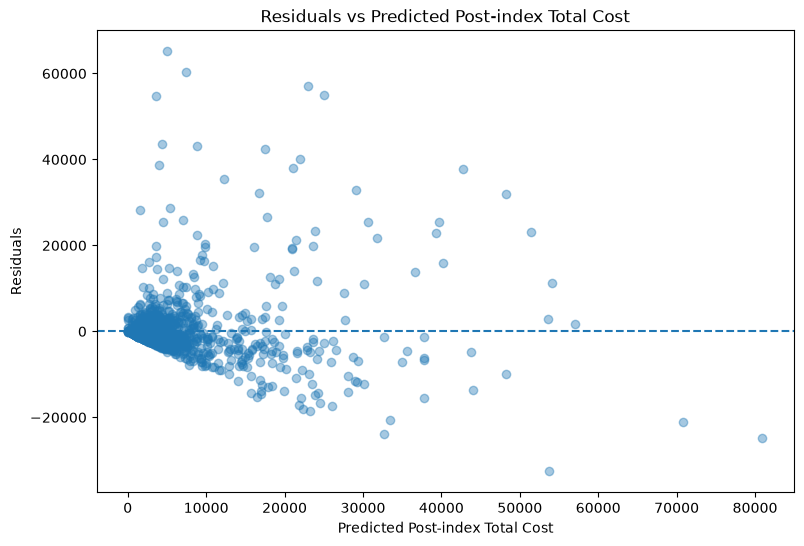

In [110]:
import matplotlib.pyplot as plt

residuals = y - y_pred

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Post-index Total Cost")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Post-index Total Cost")

plt.show()

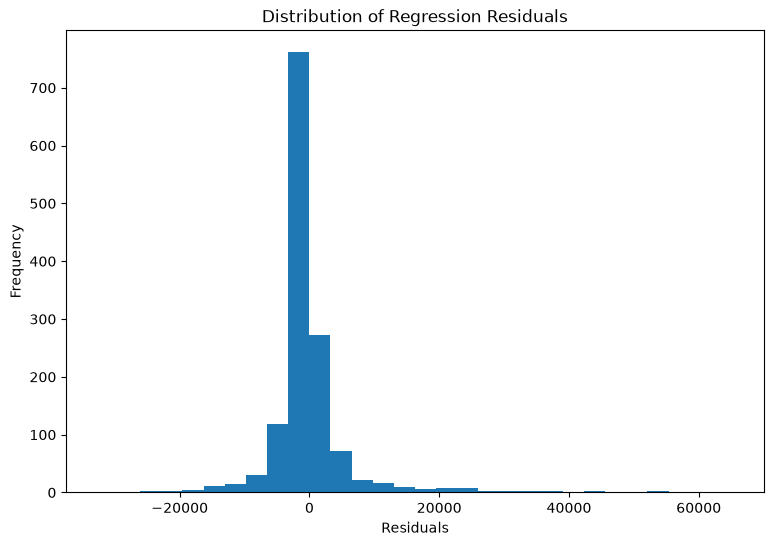

In [111]:
plt.figure(figsize=(9, 6))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Residuals")

plt.show()

In [112]:
diagnostic_data = pd.DataFrame({
    "predicted_cost": y_pred,
    "absolute_residual": np.abs(residuals)
})

diagnostic_data["prediction_group"] = pd.qcut(
    diagnostic_data["predicted_cost"],
    q=4,
    duplicates="drop"
)

diagnostic_summary = diagnostic_data.groupby(
    "prediction_group",
    observed=True
)["absolute_residual"].agg(
    ["count", "mean", "median"]
)

diagnostic_summary.round(2)

,count,mean,median
prediction_group,,,
"(73.925, 2226.021]",360,1159.81,849.53
"(2226.021, 3542.737]",335,1857.70,1699.11
"(3542.737, 6030.285]",338,3168.95,2214.29
"(6030.285, 80938.997]",345,7799.23,4742.08


### 8. Regression Diagnostics — Residual Variability

Residual diagnostics showed that the absolute prediction error increased substantially across higher predicted-cost groups.

The mean absolute residual increased from approximately €1,160 in the lowest predicted-cost group to approximately €7,799 in the highest predicted-cost group. This pattern suggests that the variability of prediction errors is not constant across the range of predicted healthcare costs.

This finding is consistent with potential heteroscedasticity, which is common in healthcare cost data because a relatively small number of patients may generate substantially higher costs.

Therefore, the linear regression results should be interpreted with caution. The model provides useful information about adjusted associations and overall model fit, but prediction uncertainty appears to be greater among patients with higher healthcare costs.

The observed heteroscedasticity does not invalidate the exploratory value of the model, but it represents an important limitation when interpreting standard errors and statistical significance from ordinary least squares regression.

In [113]:
residual_autocorr = np.corrcoef(
    residuals[:-1],
    residuals[1:]
)[0, 1]

print(
    "Residual lag-1 correlation:",
    round(residual_autocorr, 4)
)

Residual lag-1 correlation: -0.0186


### 8.1 Model Diagnostics — Overall Assessment

The regression diagnostics provided several important insights into model performance.

The residuals showed no meaningful lag-1 correlation (r = -0.019), suggesting no notable residual dependence in this diagnostic check.

However, the analysis of residual variability showed that prediction errors increased substantially at higher predicted cost levels, indicating potential heteroscedasticity.

This pattern is plausible for healthcare cost data, where costs are often highly variable and a relatively small number of patients may have substantially higher healthcare expenditures.

Overall, the linear regression model provides a useful framework for evaluating adjusted associations between healthcare utilization, comorbidity burden, medication adherence, and post-index healthcare costs. However, the presence of heteroscedasticity means that coefficient significance and uncertainty should be interpreted cautiously.

The model should therefore be viewed primarily as an analytical tool for understanding adjusted associations rather than as a causal or definitive predictive model.

## 8.2 Final Statistical Analysis Summary

The statistical analysis extended the exploratory findings by formally evaluating the relationships between medication adherence, healthcare utilization, comorbidity burden, and post-index healthcare costs.

The comparison between patients with PDC < 80% and PDC ≥ 80% showed no statistically significant difference in mean post-index healthcare costs (Welch's t-test, p = 0.613). The observed mean cost difference of approximately 4.67% was therefore not considered statistically significant.

Healthcare utilization measures showed statistically significant positive associations with post-index healthcare costs. Inpatient admissions demonstrated the strongest correlation (r = 0.600), followed by outpatient visits (r = 0.551), total length of stay (r = 0.503), and emergency room visits (r = 0.313). Comorbidity count also showed a statistically significant but weaker positive association (r = 0.231). All correlation tests had p < 0.001.

The multivariable linear regression model explained approximately 54.5% of the variation in post-index healthcare costs (R² = 0.545). After adjustment for the other variables, inpatient admissions, outpatient visits, emergency room visits, total length of stay, and comorbidity count remained statistically significant positive predictors of post-index cost. The PDC ≥ 80% indicator was not statistically significant (β = 191.38, p = 0.625).

Regression diagnostics indicated potential heteroscedasticity, with prediction errors increasing substantially at higher predicted cost levels. Therefore, the regression results should be interpreted as adjusted associations rather than causal effects or definitive predictions.

Overall, the statistical analysis suggests that healthcare utilization is more strongly associated with post-index healthcare costs than medication adherence status or comorbidity burden alone in this sample.

# 9. Business Insights & Recommendations

The statistical analysis identified several important patterns in post-index healthcare costs.

The findings indicate that healthcare utilization, particularly inpatient admissions, outpatient visits, emergency room visits, and length of stay, is strongly associated with higher post-index healthcare costs.

Medication adherence, measured using the PDC ≥ 80% threshold, did not show a statistically significant independent association with post-index total healthcare costs in the analyzed sample.

This section translates the analytical findings into practical healthcare insights and potential recommendations for cost management, utilization monitoring, and future analytical work.

## 9.1 Key Findings

The analysis identified several key findings regarding post-index healthcare costs.

1. **Healthcare utilization was strongly associated with post-index costs.**  
   Inpatient admissions showed the strongest correlation with post-index total healthcare cost (r = 0.600), followed by outpatient visits (r = 0.551) and total length of stay (r = 0.503). Emergency room visits also showed a positive association (r = 0.313).

2. **Higher healthcare utilization was associated with higher costs.**  
   The multivariable regression confirmed that inpatient admissions, outpatient visits, emergency room visits, and total length of stay remained positively and statistically significantly associated with post-index healthcare costs after adjustment for the other variables in the model.

3. **Comorbidity burden showed a weaker but significant association with costs.**  
   Comorbidity count was positively associated with post-index costs (r = 0.231) and remained statistically significant in the multivariable model (β = 417.69, p < 0.001).

4. **Medication adherence did not show a statistically significant association with costs.**  
   Patients with PDC ≥ 80% had a slightly lower mean cost than patients with PDC < 80%, but the difference was not statistically significant (Welch's t-test, p = 0.613). In the multivariable model, the PDC ≥ 80% indicator also remained non-significant (β = 191.38, p = 0.625).

5. **The multivariable model explained a meaningful proportion of cost variation.**  
   The regression model achieved an R² of 0.545, indicating that approximately 54.5% of the variation in post-index healthcare costs was explained by the variables included in the model.

Overall, the results suggest that healthcare utilization is more strongly associated with post-index healthcare costs than medication adherence status in this sample.

##  Healthcare Utilization Insights

Healthcare utilization emerged as the strongest overall driver associated with post-index healthcare costs in the analyzed sample.

Inpatient admissions showed the strongest correlation with post-index total healthcare cost (r = 0.600) and the largest adjusted regression coefficient (β = 11,351.48, p < 0.001). This indicates that inpatient care is associated with substantially higher healthcare expenditure compared with the other utilization measures included in the model.

Outpatient visits also showed a strong positive association with cost (r = 0.551; β = 438.91, p < 0.001). Although the adjusted cost increase per outpatient visit was considerably smaller than for inpatient admissions, the relatively frequent occurrence of outpatient visits makes this an important component of overall healthcare utilization.

Emergency room visits showed a moderate positive association with cost (r = 0.313; β = 1,940.64, p < 0.001). This suggests that emergency care utilization represents an important cost-related indicator in the analyzed population.

Total length of stay was also positively associated with post-index costs (r = 0.503; β = 445.61, p = 0.0001). Longer hospital stays are therefore associated with higher costs, although length of stay and inpatient utilization should be considered together when interpreting the results.

From a healthcare management perspective, these findings suggest that monitoring high levels of healthcare utilization may help identify patients with potentially higher future healthcare costs. In particular, inpatient admissions, emergency department use, and prolonged hospital stays may be useful indicators for targeted utilization management and resource planning.

However, these associations should not be interpreted as evidence that reducing utilization alone will necessarily reduce costs, since the underlying clinical needs of patients may contribute to both higher utilization and higher expenditure.

##  Medication Adherence Insight

Medication adherence was evaluated using the proportion of days covered (PDC), with 80% used as the threshold for defining higher adherence.

Patients with PDC ≥ 80% had a mean post-index healthcare cost of €5,799.53 compared with €6,083.83 among patients with PDC < 80%. This represents an observed mean cost difference of approximately -4.67%.

However, the difference was not statistically significant based on the Welch's t-test (p = 0.613). Furthermore, medication adherence remained non-significant in the multivariable regression model after adjusting for healthcare utilization and comorbidity burden (β = 191.38, p = 0.625).

Therefore, the observed difference in mean costs should not be interpreted as evidence that higher medication adherence reduces healthcare costs in this sample.

From a healthcare management perspective, this finding highlights the importance of distinguishing between an observed difference and a statistically supported association. Medication adherence may still be clinically important, but its relationship with healthcare costs may depend on additional factors that are not captured or controlled for in the current analysis.

Future analyses could investigate medication adherence using continuous PDC values rather than only the 80% threshold, as well as examining specific medication classes, disease groups, and longer follow-up periods.

##  Business / Healthcare Recommendations

Based on the findings of the analysis, several potential recommendations can be derived for healthcare organizations.

### 1. Monitor high healthcare utilization

Patients with frequent inpatient admissions, outpatient visits, or emergency room utilization may represent groups with substantially higher healthcare costs.

Healthcare organizations could use utilization indicators to identify patients with high resource use and prioritize them for further clinical or case-management review.

### 2. Monitor inpatient admissions and length of stay

Inpatient admissions showed the strongest adjusted association with post-index healthcare costs, while total length of stay was also positively associated with cost.

Monitoring admission patterns and prolonged hospital stays may therefore support resource planning and identification of patients who require additional review.

These indicators should be used to support appropriate care management rather than to discourage clinically necessary healthcare utilization.

### 3. Pay attention to emergency department utilization

Emergency room utilization showed a statistically significant positive association with post-index healthcare costs.

Healthcare organizations could investigate whether frequent emergency utilization is associated with potentially preventable patterns, such as gaps in outpatient follow-up or care coordination.

Any intervention should be based on clinical context rather than utilization alone.

### 4. Consider comorbidity burden in cost management

Comorbidity count remained significantly associated with higher post-index healthcare costs after adjustment for utilization measures.

Patients with multiple comorbidities may therefore benefit from coordinated and integrated care approaches that consider their overall healthcare needs rather than individual conditions in isolation.

### 5. Do not interpret medication adherence as a cost-reduction mechanism based on this analysis

Medication adherence did not show a statistically significant independent association with post-index healthcare costs in the current sample.

Therefore, the results do not provide sufficient evidence to recommend increasing medication adherence specifically as a cost-reduction strategy based on this analysis alone.

Medication adherence remains an important clinical measure, but its relationship with healthcare utilization and costs should be evaluated in more detailed analyses.

### Overall recommendation

The strongest analytical signal in this project relates to healthcare utilization rather than medication adherence. Future healthcare analytics initiatives could therefore focus on identifying high-utilization patient groups, understanding the underlying clinical drivers of utilization, and evaluating opportunities for appropriate care coordination and resource planning.

##  Limitations & Future Analysis

Several limitations should be considered when interpreting the findings of this analysis.

### 1. Observational data

The analysis is based on observational patient data. Therefore, the identified relationships represent associations and cannot be interpreted as causal effects.

### 2. Limited information on clinical context

The dataset contains healthcare utilization, cost, medication adherence, and comorbidity-related variables, but may not capture all clinical and socioeconomic factors that influence healthcare costs.

Factors such as disease severity, treatment complexity, socioeconomic status, and access to healthcare may contribute to differences in healthcare utilization and costs.

### 3. Medication adherence definition

Medication adherence was primarily evaluated using a binary PDC threshold of 80%.

This approach simplifies a continuous measure and may hide potentially important differences between patients with moderately and very high adherence.

Future analyses could evaluate PDC as a continuous variable and investigate whether different adherence thresholds produce different results.

### 4. Healthcare cost distribution

Healthcare costs showed substantial variability, particularly among patients with higher predicted costs. Regression diagnostics indicated potential heteroscedasticity.

Future modeling could therefore consider alternative approaches, such as log-transformed cost models or generalized linear models with appropriate distributions, depending on the characteristics of the data.

### 5. Model scope

The multivariable regression model explained approximately 54.5% of the variation in post-index healthcare costs.

Although this represents meaningful explanatory power, a considerable proportion of cost variation remained unexplained.

Future models could incorporate additional patient characteristics, clinical conditions, medication categories, demographic factors, and temporal patterns.

### 6. Future analysis

Further analysis could investigate:

- medication adherence as a continuous variable;
- specific medication classes and disease groups;
- high-cost patient segments;
- relationships between emergency utilization and inpatient admissions;
- additional predictors of healthcare costs;
- longer follow-up periods;
- alternative regression approaches designed for healthcare cost data.

These extensions could provide a more detailed understanding of the factors associated with healthcare utilization and post-index healthcare costs.

# 10. Final Conclusions

This project analyzed patient-level healthcare data to investigate the factors associated with post-index total healthcare costs.

The analysis combined data preparation, exploratory data analysis, healthcare utilization analysis, statistical hypothesis testing, correlation analysis, and multivariable linear regression to evaluate relationships between healthcare utilization, comorbidity burden, medication adherence, and healthcare costs.

The results consistently showed that healthcare utilization was strongly associated with post-index healthcare costs. In particular, inpatient admissions demonstrated the strongest relationship with cost, while outpatient visits, emergency room visits, and total length of stay also showed statistically significant positive associations.

Comorbidity burden showed a weaker but statistically significant relationship with healthcare costs. This suggests that patients with greater comorbidity burden may also experience higher healthcare expenditure, although the analysis does not establish a causal relationship.

Medication adherence, measured using the PDC ≥ 80% threshold, did not show a statistically significant independent association with post-index healthcare costs in this sample. Although the high-adherence group had a slightly lower mean cost, the observed difference was not statistically significant.

The multivariable regression model explained approximately 54.5% of the variation in post-index healthcare costs. The model identified healthcare utilization and comorbidity burden as significant adjusted predictors, while medication adherence remained non-significant.

Overall, the findings suggest that healthcare utilization patterns are more strongly associated with post-index healthcare costs than medication adherence status in the analyzed population.

From a healthcare analytics perspective, the project demonstrates how patient-level data can be transformed into actionable insights through data cleaning, exploratory analysis, statistical testing, regression modeling, visualization, and careful interpretation.

The findings should be interpreted as associations rather than causal effects. Further analysis using additional clinical, demographic, medication-specific, and longitudinal variables could provide a more comprehensive understanding of healthcare cost drivers.